In [4]:
import xarray as xr

# Construct path for the very first file
base_path = "/home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT_SINGLECONF/POST/GUES"
init_str = "20240319180000" 
test_file = f"{base_path}/{init_str}/WRF.D20240319180000.T2D.M001.nc"

try:
    ds_test = xr.open_dataset(test_file)
    print("--- DATA VARIABLES ---")
    print(list(ds_test.data_vars))
    print("\n--- COORDINATES ---")
    print(list(ds_test.coords))
    LAT_NAME = "XLAT"       # UPDATE THIS based on Cell 1
    LON_NAME = "XLONG"
    lat = ds_test[LAT_NAME].squeeze().values
    lon = ds_test[LON_NAME].squeeze().values
    # print range of lat and lon values
    print(f"\nLatitude range: {lat.min()} to {lat.max()}")
    print(f"Longitude range: {lon.min()} to {lon.max()}")
    ds_test.close()
except FileNotFoundError:
    print(f"Could not find the test file at: {test_file}")
    print("Please double check the directory path or date strings.")

--- DATA VARIABLES ---
['MCAPE', 'PSFC', 'T2', 'CIN', 'Q2', 'PP', 'MDBZ', 'UH', 'Umet10', 'Vmet10']

--- COORDINATES ---
['XLONG', 'XLAT', 'XTIME', 'y', 'x', 'Lambert_Conformal']

Latitude range: -49.43363571166992 to -17.07586669921875
Longitude range: -76.70037841796875 to -47.29962158203125


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gc

# --- 1. Configuration ---
BASE_PATH = "/home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT_SINGLECONF/POST/GUES"
INIT_STR = "20240320120000"
VAR_NAME = "PP"  # UPDATE THIS based on Cell 1
DATA_MIN = 0.0
LAT_NAME = "XLAT"       # UPDATE THIS based on Cell 1
LON_NAME = "XLONG"      # UPDATE THIS based on Cell 1

# Bounding Box (South, North, West, East)

LAT_MIN, LAT_MAX = -41.5, -25.3
LON_MIN, LON_MAX = -68.6, -55.4

# Time range: 2023-03-19 12:00:00 to 2023-03-20 06:00:00 at 5 min intervals
times = pd.date_range(start="2024-03-19 12:00:00", end="2024-03-20 06:00:00", freq="5min")

def get_filepath(t, m):
    date_str = t.strftime("%Y%m%d%H%M%S")
    return f"{BASE_PATH}/{date_str}/WRF.D{date_str}.T2D.M{m:03d}.nc"

# --- 2. Processing Loop ---
time_series_data = {
    'time': [],
    'mean': [],
    'median': [],
    'min': [],
    'max': []
}

print(f"Starting processing. Total time steps: {len(times)}")

for i, t in enumerate(times):
    if i % 10 == 0: 
        print(f"Processing time step {i}/{len(times)}: {t}")
        
    step_member_means = []
    step_member_min = []
    step_member_max = []
    step_member_median = []
    
    for m in range(1, 61):
        filepath = get_filepath(t, m)
        try:
            ds = xr.open_dataset(filepath)
            
            # Extract coordinates and variable
            lat = ds[LAT_NAME].squeeze().values
            lon = ds[LON_NAME].squeeze().values
            data = ds[VAR_NAME].squeeze().values
            data[data <= DATA_MIN] = np.nan  # Mask out values below the threshold
            # --- THE FIX ---
            # If the data is 3D (e.g., 12 vertical levels), take the maximum along the vertical axis (axis 0).
            # This creates a 2D "Composite Reflectivity" map.
            if data.ndim == 3:
                data = np.nanmax(data, axis=0) 
            # ---------------
            
            # Create a 2D boolean mask for your bounding box
            mask = (lat >= LAT_MIN) & (lat <= LAT_MAX) & (lon >= LON_MIN) & (lon <= LON_MAX)
            
            # Extract only the data within the bounding box
            subset_data = data[mask]
            
            # Calculate the spatial mean for this specific member at this time
            spatial_sum = np.nansum(subset_data)
            step_member_means.append(spatial_sum)
            
            # Explicit memory cleanup
            ds.close()
            del ds, lat, lon, data, mask, subset_data
            
        except:
            continue 
            
    # Calculate ENSEMBLE metrics across all available members
    if step_member_means:
        print(f"  Ensemble Mean: {np.mean(step_member_means):.2f}")
        time_series_data['time'].append(t)
        time_series_data['mean'].append(np.mean(step_member_means))
        time_series_data['median'].append(np.median(step_member_means))
        time_series_data['min'].append(np.min(step_member_means))
        time_series_data['max'].append(np.max(step_member_means))

    # Force garbage collection
    del step_member_means
    gc.collect()

print("Processing complete!")

Starting processing. Total time steps: 217
Processing time step 0/217: 2024-03-19 12:00:00
  Ensemble Mean: 2294.41
  Ensemble Mean: 2284.07
  Ensemble Mean: 2239.88
  Ensemble Mean: 2244.67
  Ensemble Mean: 2243.95
  Ensemble Mean: 2204.61
  Ensemble Mean: 2235.23
  Ensemble Mean: 2241.89
  Ensemble Mean: 2263.86
  Ensemble Mean: 2319.84
Processing time step 10/217: 2024-03-19 12:50:00
  Ensemble Mean: 2277.46
  Ensemble Mean: 2275.56
  Ensemble Mean: 2240.45
  Ensemble Mean: 2158.37
  Ensemble Mean: 2157.13
  Ensemble Mean: 2123.51
  Ensemble Mean: 2163.31
  Ensemble Mean: 2126.69
  Ensemble Mean: 2038.04
  Ensemble Mean: 1992.50
Processing time step 20/217: 2024-03-19 13:40:00
  Ensemble Mean: 1980.80
  Ensemble Mean: 1969.17
  Ensemble Mean: 1920.15
  Ensemble Mean: 1910.22
  Ensemble Mean: 1856.97
  Ensemble Mean: 1859.60
  Ensemble Mean: 1833.26
  Ensemble Mean: 1851.58
  Ensemble Mean: 1816.49
  Ensemble Mean: 1800.70
Processing time step 30/217: 2024-03-19 14:30:00
  Ensemble M

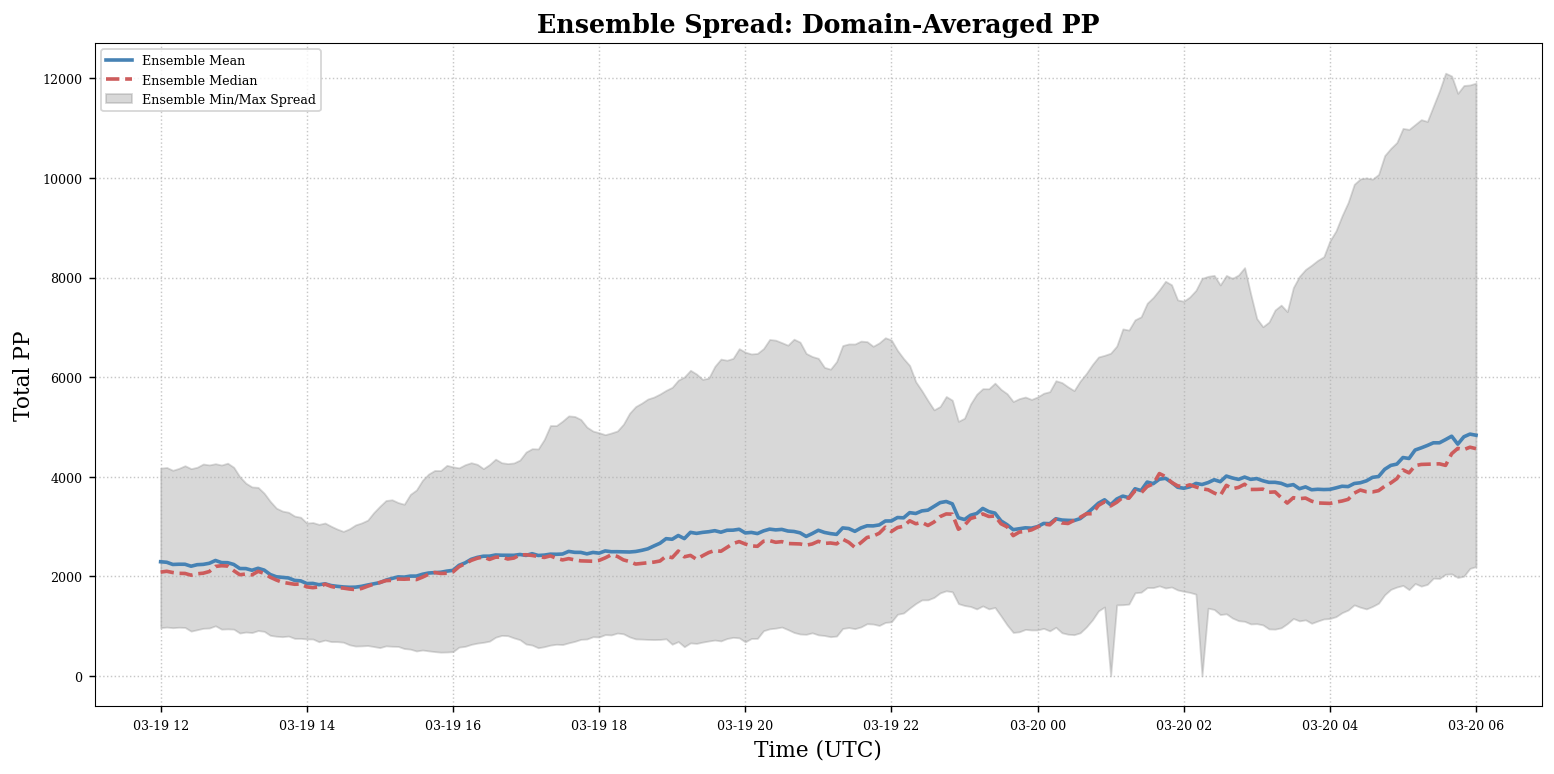

In [49]:
df = pd.DataFrame(time_series_data)
df.set_index('time', inplace=True)

plt.figure(figsize=(12, 6))

# Plot the min-max spread as a shaded region
plt.fill_between(df.index, df['min'], df['max'], color='gray', alpha=0.3, label='Ensemble Min/Max Spread')

# Plot the mean and median
plt.plot(df.index, df['mean'], color='SteelBlue', linewidth=2, label='Ensemble Mean')
plt.plot(df.index, df['median'], color='IndianRed', linestyle='--', linewidth=2, label='Ensemble Median')

plt.title(f"Ensemble Spread: Domain-Averaged {VAR_NAME}", fontsize=14, fontweight='bold')
plt.xlabel("Time (UTC)", fontsize=12)
plt.ylabel(f"Total {VAR_NAME}", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()

plt.show()

Generating Sequence A (Spatial Expansion)...


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,
/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,
/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarnin

Successfully saved: WRF_Spatial_Sequence_A.png


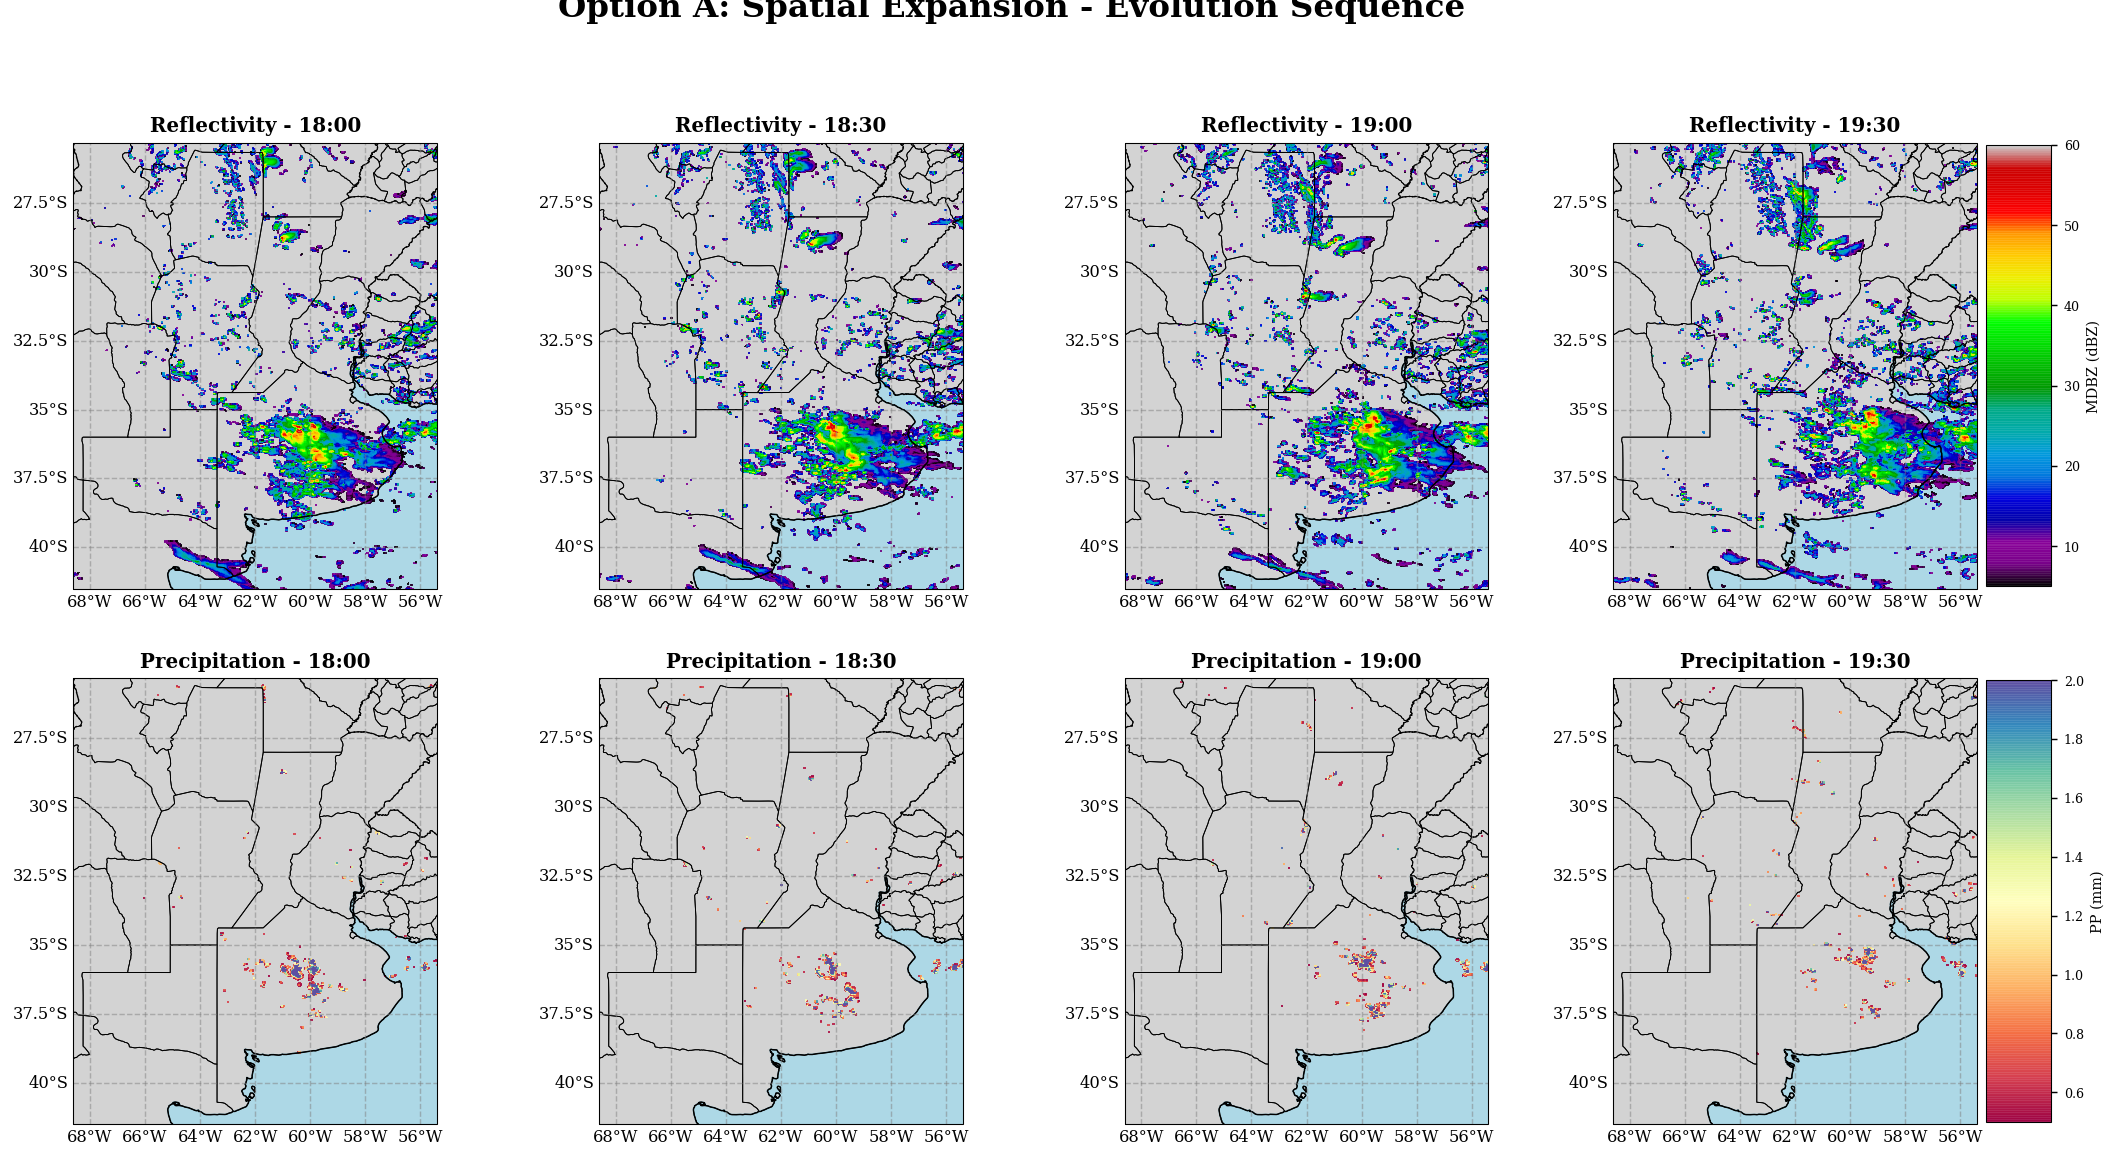

Generating Sequence B (Localized Intensification)...


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,
/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,
/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarnin

Successfully saved: WRF_Intensification_Sequence_B.png


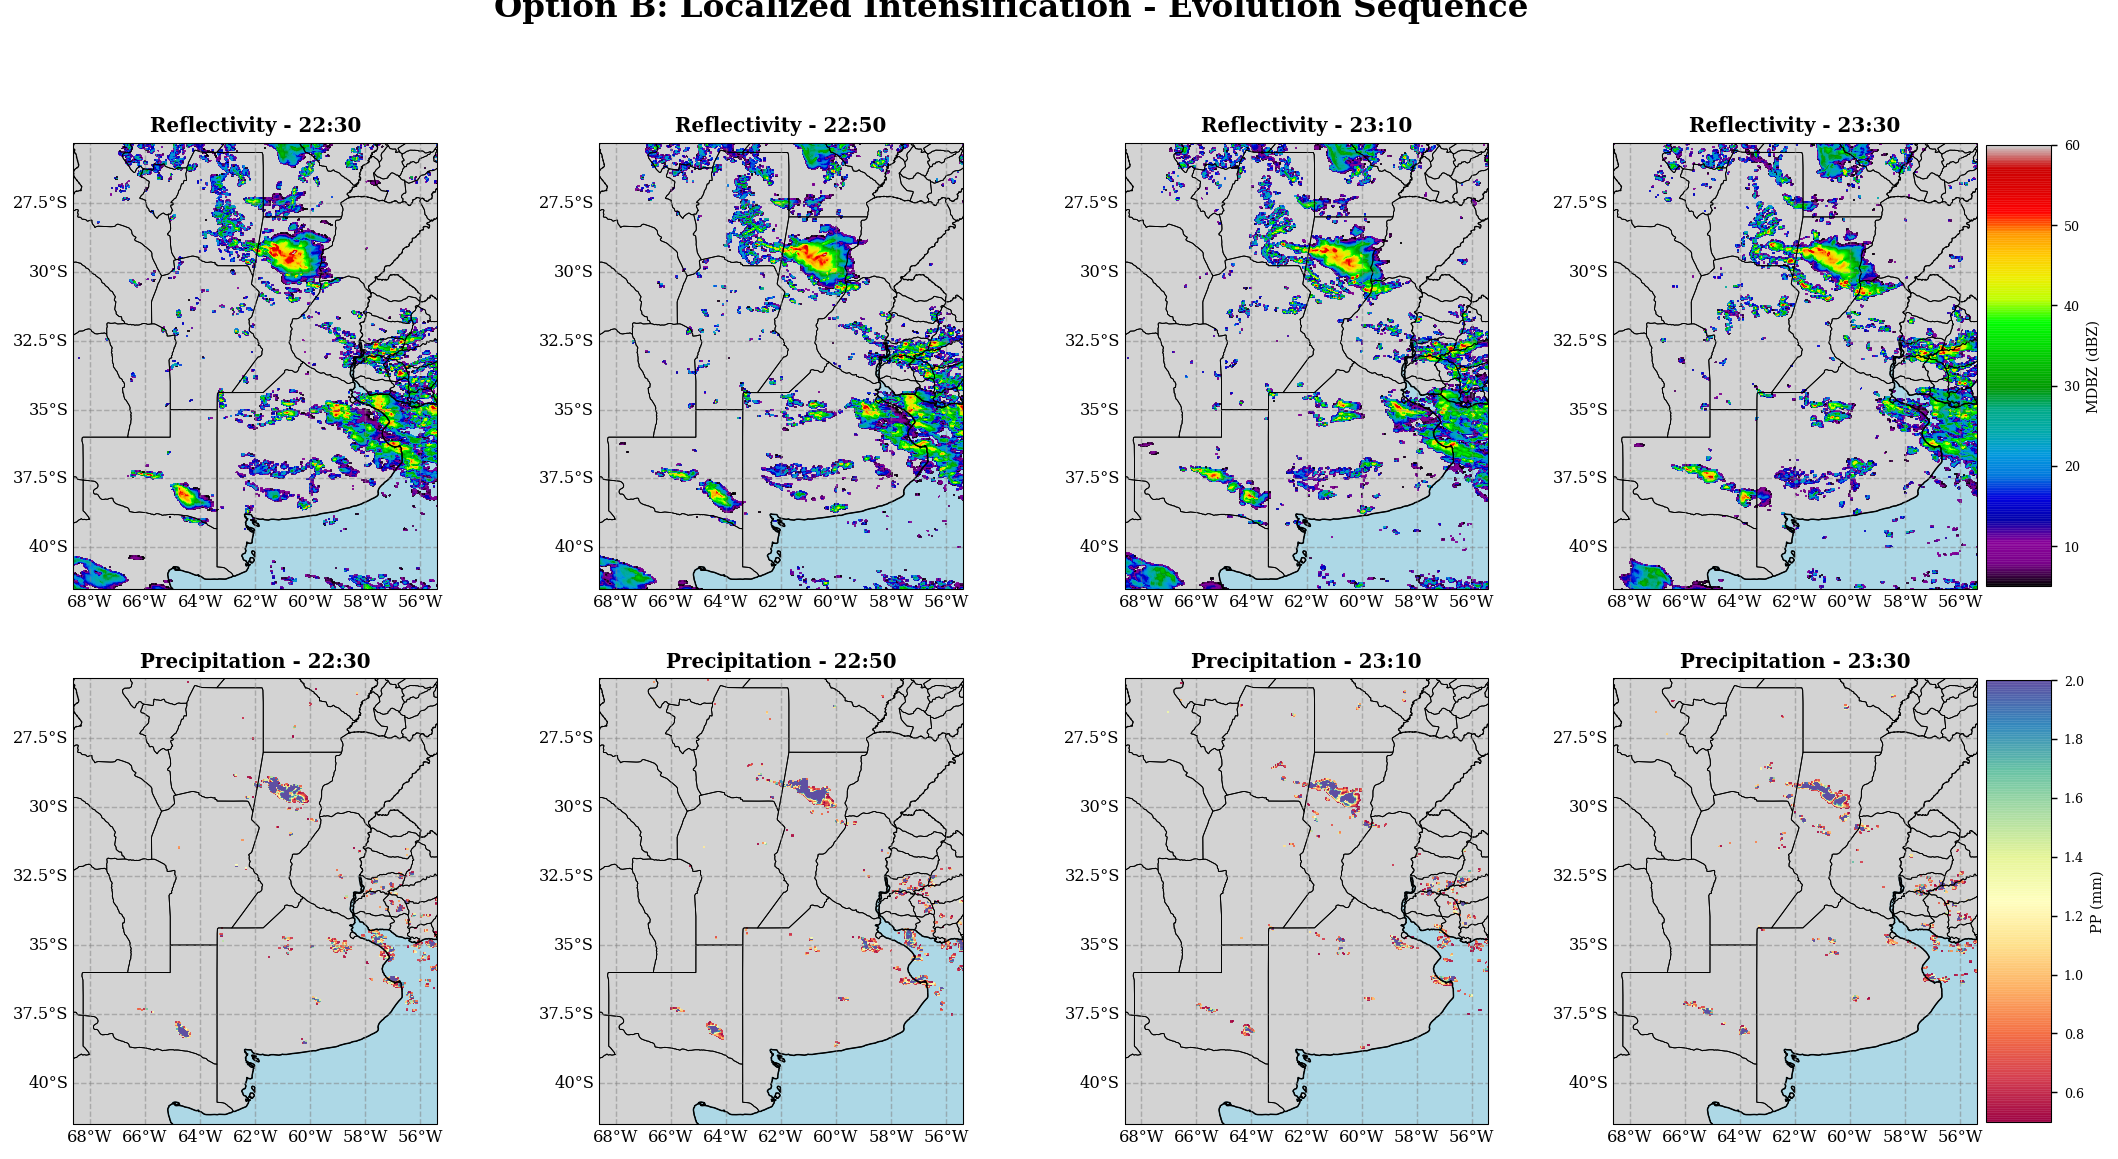

In [80]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Configuration ---
BASE_PATH = "/home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT_SINGLECONF/POST/GUES"
INIT_STR = "2024031912"
MEMBER = 1  

VAR_MDBZ = "MDBZ"     
VAR_PP = "PP"     
LAT_NAME = "XLAT"
LON_NAME = "XLONG"

# Area of Interest
LAT_MIN, LAT_MAX = -41.5, -25.3
LON_MIN, LON_MAX = -68.6, -55.4

def get_filepath(dt_obj, member_int):
    date_str = dt_obj.strftime("%Y%m%d%H%M%S")
    return f"{BASE_PATH}/{date_str}/WRF.D{date_str}.T2D.M{member_int:03d}.nc"

def plot_spatial_panel(ax, lon, lat, data, title, cmap, vmin, vmax):
    """Plots a geospatial 2D field using Cartopy."""
    
    # 1. Add Geographical Features
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, linestyle=':', edgecolor='black')
    #add states
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black')
    
    # 2. Mask values below or equal to zero
    # np.where works perfectly here: if data > 0, keep it. Else, set to NaN (transparent).
    data_masked = np.where(data > vmin, data, np.nan)
    
    # 3. Plot the data with transparency (alpha)
    # transform=ccrs.PlateCarree() is crucial so Cartopy knows our data is in standard Lat/Lon
    im = ax.pcolormesh(lon, lat, data_masked, transform=ccrs.PlateCarree(),
                       cmap=cmap, vmin=vmin, vmax=vmax, shading='auto', alpha=0.9)
    
    # 4. Set map boundaries
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    
    # 5. Format gridlines and labels
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    return im

def generate_sequence_figure(times, title_prefix, figname):
    """Generates a multi-panel sequence based on a list of times."""
    n_panels = len(times)
    
    # Create subplots dynamically with the PlateCarree projection attached to each axis
    fig, axes = plt.subplots(2, n_panels, figsize=(5 * n_panels, 10), 
                             subplot_kw={'projection': ccrs.PlateCarree()}, 
                             constrained_layout=True)
    
    fig.suptitle(f"{title_prefix} - Evolution Sequence", fontsize=18, fontweight='bold')
    
    im_mdbz, im_pp = None, None
    
    for col, t in enumerate(times):
        filepath = get_filepath(t, MEMBER)
        
        # Handle 1D axes arrays properly for dynamic sizing
        ax_mdbz = axes[0, col] if n_panels > 1 else axes[0]
        ax_pp = axes[1, col] if n_panels > 1 else axes[1]
        
        try:
            ds = xr.open_dataset(filepath)
            lat = ds[LAT_NAME].squeeze().values
            lon = ds[LON_NAME].squeeze().values
            
            data_mdbz = ds[VAR_MDBZ].squeeze().values
            data_pp = ds[VAR_PP].squeeze().values
            
            if data_mdbz.ndim == 3:
                data_mdbz = np.max(data_mdbz, axis=0)
                
            # Plot Top Row (MDBZ)
            im_mdbz = plot_spatial_panel(ax_mdbz, lon, lat, data_mdbz, 
                                         f"Reflectivity - {t.strftime('%H:%M')}", 
                                         cmap='nipy_spectral', vmin=5, vmax=60) # Raised vmin slightly to hide noise
            
            # Plot Bottom Row (PP) - for spectral precipitation
            im_pp = plot_spatial_panel(ax_pp, lon, lat, data_pp, 
                                       f"Precipitation - {t.strftime('%H:%M')}", 
                                       cmap='Spectral', vmin=0.5, vmax=2)
            ds.close()
            
        except FileNotFoundError:
            for ax in [ax_mdbz, ax_pp]:
                ax.text(0.5, 0.5, f"Missing File:\n{t.strftime('%H:%M')}", 
                        ha='center', va='center', transform=ax.transAxes, fontsize=10)
                ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
                ax.add_feature(cfeature.LAND, facecolor='lightgray')

    # Add shared colorbars at the bottom of the figure
    if im_mdbz:
        fig.colorbar(im_mdbz, ax=axes[0, -1], orientation='vertical', shrink=0.99, pad=0.02, aspect=200, label=f"{VAR_MDBZ} (dBZ)")
    if im_pp:
        fig.colorbar(im_pp, ax=axes[1, -1], orientation='vertical', shrink=0.99, pad=0.02, aspect=80, label=f"{VAR_PP} (mm)")
        
    #plt.savefig(figname, dpi=200, bbox_inches='tight')
    plt.tight_layout()
    print(f"Successfully saved: {figname}")
    plt.show()

# --- Execution ---

# Sequence A: 4 time steps (Every 30 mins) showing spatial expansion
times_A = [
    datetime(2024, 3, 19, 18, 0, 0),
    datetime(2024, 3, 19, 18, 30, 0),
    datetime(2024, 3, 19, 19, 0, 0),
    datetime(2024, 3, 19, 19, 30, 0)
]
print("Generating Sequence A (Spatial Expansion)...")
generate_sequence_figure(times_A, "Option A: Spatial Expansion", "WRF_Spatial_Sequence_A.png")

# Sequence B: 4 time steps (Every 20 mins) showing rapid intensification
times_B = [
    datetime(2024, 3, 19, 22, 30, 0),
    datetime(2024, 3, 19, 22, 50, 0),
    datetime(2024, 3, 19, 23, 10, 0),
    datetime(2024, 3, 19, 23, 30, 0)
]
print("Generating Sequence B (Localized Intensification)...")
generate_sequence_figure(times_B, "Option B: Localized Intensification", "WRF_Intensification_Sequence_B.png")

Loading ensemble data...
Generating Figure 1 (20 dBZ Contour)...


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


Saved: WRF_Spaghetti_20dBZ.png


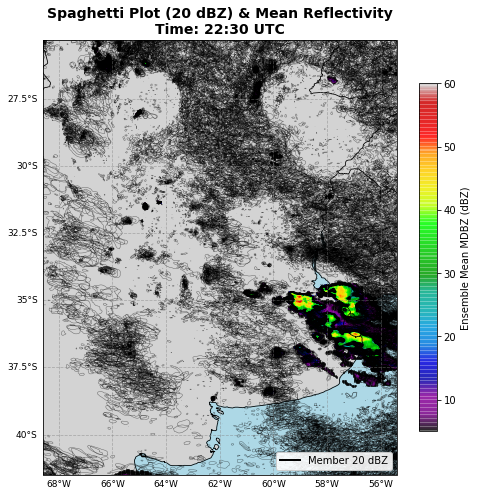

Generating Figure 2 (20 and 40 dBZ Contours)...
Saved: WRF_Spaghetti_20_40dBZ.png


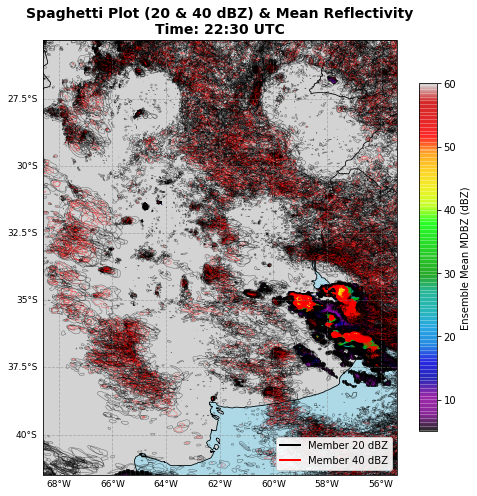

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# --- Configuration ---
BASE_PATH = "/home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT_SINGLECONF/POST/GUES"
INIT_STR = "2024031912"
VAR_MDBZ = "MDBZ"     
LAT_NAME = "XLAT"
LON_NAME = "XLONG"

# Area of Interest
LAT_MIN, LAT_MAX = -41.5, -25.3
LON_MIN, LON_MAX = -68.6, -55.4

TARGET_TIME = datetime(2024, 3, 19, 22, 30, 0)
NUM_MEMBERS = 60

def get_filepath(dt_obj, member_int):
    date_str = dt_obj.strftime("%Y%m%d%H%M%S")
    return f"{BASE_PATH}/{date_str}/WRF.D{date_str}.T2D.M{member_int:03d}.nc"

def setup_map(ax):
    """Adds Cartopy features and sets extent."""
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, linestyle='-', edgecolor='black')
    
    # State/Province boundaries (like in your provided image)
    states_provinces = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none')
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.5, linestyle=':')
    
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

print("Loading ensemble data...")
# Load all members to calculate the mean and store arrays for the spaghetti
all_members_data = []
lat, lon = None, None

for m in range(1, NUM_MEMBERS + 1):
    filepath = get_filepath(TARGET_TIME, m)
    try:
        ds = xr.open_dataset(filepath)
        if lat is None:
            lat = ds[LAT_NAME].squeeze().values
            lon = ds[LON_NAME].squeeze().values
            
        data = ds[VAR_MDBZ].squeeze().values
        if data.ndim == 3:
            data = np.max(data, axis=0)
            
        all_members_data.append(data)
        ds.close()
    except FileNotFoundError:
        print(f"Skipping missing member {m:03d}")

# Stack and calculate ensemble mean
ensemble_stack = np.stack(all_members_data)
ensemble_mean = np.mean(ensemble_stack, axis=0)
ensemble_mean_masked = np.where(ensemble_mean > 0, ensemble_mean, np.nan)

# --- Plotting Function ---
def create_spaghetti_plot(contour_levels, colors, figname, title):
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    setup_map(ax)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # 1. Plot the Ensemble Mean as the background shading
    im = ax.pcolormesh(lon, lat, ensemble_mean_masked, transform=ccrs.PlateCarree(),
                       cmap='nipy_spectral', vmin=5, vmax=60, shading='auto', alpha=0.6) # Lower alpha so contours pop
    
    # Add colorbar for the mean
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, pad=0.04)
    cbar.set_label(f"Ensemble Mean {VAR_MDBZ} (dBZ)")

    # 2. Draw the Spaghetti Contours
    # We iterate through each member and draw their contour lines
    for data in all_members_data:
        # Use contour, not contourf.
        ax.contour(lon, lat, data, levels=contour_levels, colors=colors, 
                   linewidths=0.5, alpha=0.5, transform=ccrs.PlateCarree())

    # Create custom legend lines for the spaghetti contours
    custom_lines = [plt.Line2D([0], [0], color=c, lw=2) for c in colors]
    labels = [f"Member {lvl} dBZ" for lvl in contour_levels]
    ax.legend(custom_lines, labels, loc='lower right', framealpha=0.9)

    plt.savefig(figname, dpi=200, bbox_inches='tight')
    print(f"Saved: {figname}")
    plt.show()

# --- Execution ---

# Figure 1: Single Contour at 20 dBZ (Storm Boundary)
print("Generating Figure 1 (20 dBZ Contour)...")
create_spaghetti_plot(contour_levels=[20], colors=['black'], 
                      figname="WRF_Spaghetti_20dBZ.png", 
                      title=f"Spaghetti Plot (20 dBZ) & Mean Reflectivity\nTime: {TARGET_TIME.strftime('%H:%M')} UTC")

# Figure 2: Double Contour at 20 dBZ and 40 dBZ (Boundary vs Core)
print("Generating Figure 2 (20 and 40 dBZ Contours)...")
create_spaghetti_plot(contour_levels=[20, 40], colors=['black', 'red'], 
                      figname="WRF_Spaghetti_20_40dBZ.png", 
                      title=f"Spaghetti Plot (20 & 40 dBZ) & Mean Reflectivity\nTime: {TARGET_TIME.strftime('%H:%M')} UTC")

Loading ensemble data...
Generating Spread/Mean Figure...


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,
/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/io/__init__.py:260: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/50m/physical/ne_50m_land.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/io/__init__.py:260: DownloadWarning: Downloading: https://naciscdn.org/naturalearth/50m/physical/ne_50m_ocean.zip
  warnings.warn('Downloading: {}'.format(url), DownloadWarning)
/home/

Saved: WRF_Spread_and_Mean.png


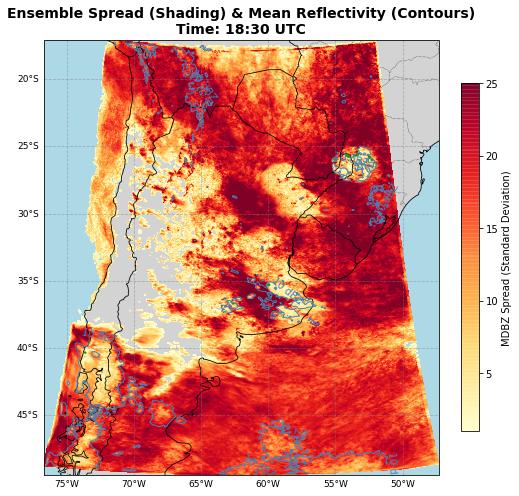

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Configuration ---
BASE_PATH = "/home/jruiz/datosdemerzel/PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031900_5MIN_WINIT_SINGLECONF/POST/GUES"
INIT_STR = "2024031912"
VAR_MDBZ = "MDBZ"     
LAT_NAME = "XLAT"
LON_NAME = "XLONG"

# Area of Interest
#LAT_MIN, LAT_MAX = -41.5, -25.3
#LON_MIN, LON_MAX = -68.6, -55.4

#full domain
LAT_MIN, LAT_MAX = -49.43363571166992, -17.07586669921875
LON_MIN, LON_MAX = -76.70037841796875, -47.29962158203125

TARGET_TIME = datetime(2024, 3, 19, 18, 30, 0)
NUM_MEMBERS = 60

def get_filepath(dt_obj, member_int):
    date_str = dt_obj.strftime("%Y%m%d%H%M%S")
    return f"{BASE_PATH}/{date_str}/WRF.D{date_str}.T2D.M{member_int:03d}.nc"

def setup_map(ax):
    """Adds Cartopy features and sets extent."""
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, linestyle='-', edgecolor='black')
    
    states_provinces = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none')
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.5, linestyle=':')
    
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

print("Loading ensemble data...")
all_members_data = []
lat, lon = None, None

for m in range(1, NUM_MEMBERS + 1):
    filepath = get_filepath(TARGET_TIME, m)
    try:
        ds = xr.open_dataset(filepath)
        if lat is None:
            lat = ds[LAT_NAME].squeeze().values
            lon = ds[LON_NAME].squeeze().values
            
        data = ds[VAR_MDBZ].squeeze().values
        if data.ndim == 3:
            data = np.max(data, axis=0)
            
        all_members_data.append(data)
        ds.close()
    except FileNotFoundError:
        pass # Silently skip missing files for this step

# --- Statistical Calculations ---
ensemble_stack = np.stack(all_members_data)

# 1. Calculate Ensemble Mean
ensemble_mean = np.mean(ensemble_stack, axis=0)

# 2. Calculate Ensemble Spread (Standard Deviation)
ensemble_spread = np.std(ensemble_stack, axis=0)

# Mask out areas with near-zero spread so the basemap shows through
spread_masked = np.where(ensemble_spread > 1.0, ensemble_spread, np.nan)

# --- Plotting ---
print("Generating Spread/Mean Figure...")
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
setup_map(ax)

ax.set_title(f"Ensemble Spread (Shading) & Mean Reflectivity (Contours)\nTime: {TARGET_TIME.strftime('%H:%M')} UTC", 
             fontsize=14, fontweight='bold')

# 1. Plot Spread as Shading
# Using YlOrRd (Yellow to Red). vmin=1, vmax=25 is usually a good scale for dBZ standard deviation.
im = ax.pcolormesh(lon, lat, spread_masked, transform=ccrs.PlateCarree(),
                   cmap='YlOrRd', vmin=1, vmax=25, shading='auto', alpha=0.85)

cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, pad=0.04)
cbar.set_label(f"{VAR_MDBZ} Spread (Standard Deviation)")

# 2. Plot Mean as Contours
contour_levels = [10, 40]
# Use different line styles/widths to tell them apart without a legend
line_widths = [1.0, 1.5] 
colors = ['SteelBlue', 'ForestGreen']
contours = ax.contour(lon, lat, ensemble_mean, levels=contour_levels, 
                      colors=colors, linewidths=line_widths, transform=ccrs.PlateCarree())

# Add inline labels to the contour lines so you know which is 10, 20, and 40
ax.clabel(contours, inline=True, fontsize=10, fmt='%1.0f dBZ')

plt.savefig("WRF_Spread_and_Mean.png", dpi=200, bbox_inches='tight')
print("Saved: WRF_Spread_and_Mean.png")
plt.show()

In [3]:
############### General Configuration #############
import os, glob
import numpy as np, pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── QJRMS / Wiley figure standard ────────────────────────────────────────────
MM     = 1/25.4
COL_W  = 84 * MM     # single-column width  [in]  (~3.31")
PAGE_W = 174 * MM    # full-page width      [in]  (~6.85")

plt.rcParams.update({
    'figure.dpi'      : 130,     # screen preview
    'savefig.dpi'     : 600,     # raster export
    'savefig.bbox'    : 'tight',
    'font.size'       : 8,
    'font.family'     : 'serif',
    # 'font.serif'    : ['Times New Roman'],   # uncomment if installed
    'mathtext.fontset': 'stix',
    'axes.titlesize'  : 8,
    'axes.labelsize'  : 8,
    'legend.fontsize' : 7,
    'xtick.labelsize' : 7,
    'ytick.labelsize' : 7,
    'axes.linewidth'  : 0.6,
    'lines.linewidth' : 1.2,
    'pdf.fonttype'    : 42,      # embed TrueType (avoid Type-3; journal-safe)
    'ps.fonttype'     : 42,
})

FIG_DIR = 'figures_paper'
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name, dpi=600):
    """Save as vector PDF + 600-dpi PNG for QJRMS submission."""
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIG_DIR, f'{name}.{ext}'), dpi=dpi)
    print(f'saved {name}.pdf / {name}.png')

# ── Shared palettes / labels (consistent with S4 & S5) ───────────────────────
LOC_SCALES = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
LOC_COLORS = {0.5:'#d62728', 1.0:'#ff7f0e', 1.5:'#2ca02c', 2.0:'#1f77b4',
              2.5:'#9467bd', 3.0:'#8c564b', 3.5:'#e377c2', 4.0:'#7f7f7f',
              4.5:'#bcbd22', 5.0:'#17becf'}
LOC_LABELS = {l: f'{l} km' for l in LOC_SCALES}

NTEMPS        = [1, 2, 3, 5]
NTEMP_STYLES  = {1:'-', 2:'--', 3:':', 5:'-.'}
NTEMP_MARKERS = {1:'o', 2:'s', 3:'^', 5:'D'}

STATE_VARS = ['qg', 'qr', 'qs', 'T', 'P', 'u', 'v', 'w']
VAR_LABELS = {'obs':r'$Z$', 'qg':r'$q_g$', 'qr':r'$q_r$', 'qs':r'$q_s$',
              'T':r'$T$', 'P':r'$P$', 'u':r'$u$', 'v':r'$v$', 'w':r'$w$'}

print('QJRMS figure setup ready. Columns:', f'{COL_W:.2f}" / {PAGE_W:.2f}"')

QJRMS figure setup ready. Columns: 3.31" / 6.85"


In [5]:
# ── Helpers (from S4) ─────────────────────────────────────────────────────────
def load_sweep_npz(path):
    d = np.load(path, allow_pickle=True)
    cols = [k for k in d.files if d[k].ndim == 1 and k != 'var_names']
    return pd.DataFrame({k: d[k] for k in cols})

def add_derived_cols(df):
    df['drmse_w']     = df['rmse_a_w_obs']     - df['rmse_f_w_obs']
    df['drmse_u']     = df['rmse_a_u_obs']     - df['rmse_f_u_obs']
    df['drmse_point'] = df['rmse_a_point_obs'] - df['rmse_f_point_obs']
    for metric in ('w', 'u', 'point'):
        for v in ['obs'] + STATE_VARS:
            cf, ca = f'rmse_f_{metric}_{v}', f'rmse_a_{metric}_{v}'
            if cf in df.columns and ca in df.columns:
                df[f'drmse_{metric}_{v}'] = df[ca] - df[cf]
    return df

def binned_stats(x, y, edges, min_count=10):
    centers = 0.5 * (edges[:-1] + edges[1:])
    means = np.full(len(centers), np.nan); stds = np.full(len(centers), np.nan)
    for b in range(len(centers)):
        m = (x >= edges[b]) & (x < edges[b+1]) & ~np.isnan(y)
        if m.sum() >= min_count:
            means[b] = np.nanmean(y[m]); stds[b] = np.nanstd(y[m])
    return centers, means, stds

# ── Config ───────────────────────────────────────────────────────────────────
DATA_ROOT     = '/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data'
FILTER_METHOD = 'TEnKF'
FILTER_NTEMP  = NTEMPS
SUBSAMPLE     = True
SUBSAMPLE_N   = 500000

EXPERIMENTS = [
    {'loc_scale': l,
     'directory': f'WS_sweep_test_1800_LOC{l}',
     'file_glob': f'WS_sweep_LOC{l}_sweep_Ne040_tm*.npz'}
    for l in LOC_SCALES
]

# ── Build single-obs df ───────────────────────────────────────────────────────
all_dfs = []
for exp in EXPERIMENTS:
    loc  = exp['loc_scale']
    dirp = os.path.join(DATA_ROOT, exp['directory'])
    files = sorted(glob.glob(os.path.join(dirp, exp['file_glob'])))[0:10]
    loc_dfs = []
    for fpath in files:
        try:
            raw = load_sweep_npz(fpath)
            raw = raw[(raw['method'] == FILTER_METHOD) & (raw['ntemp'].isin(FILTER_NTEMP))]
            raw['loc_scale'] = loc
            loc_dfs.append(raw)
        except Exception as e:
            print(f'  SKIP {os.path.basename(fpath)}: {e}')
    if not loc_dfs:
        print(f'loc={loc}: NO files in {exp["directory"]}'); continue
    loc_df = pd.concat(loc_dfs, ignore_index=True)
    if SUBSAMPLE:
        loc_df = loc_df.sample(n=min(SUBSAMPLE_N, len(loc_df)), random_state=42).reset_index(drop=True)
    print(f'loc={loc}: {len(files)} files -> {len(loc_df):,} rows')
    all_dfs.append(loc_df)

df = add_derived_cols(pd.concat(all_dfs, ignore_index=True))
print(f'\nSINGLE-OBS df: {len(df):,} rows | loc {sorted(df.loc_scale.unique())} | ntemp {sorted(df.ntemp.unique())}')

loc=0.5: 10 files -> 500,000 rows
loc=1.0: 10 files -> 500,000 rows
loc=1.5: 10 files -> 500,000 rows
loc=2.0: 10 files -> 500,000 rows
loc=2.5: 10 files -> 500,000 rows
loc=3.0: 10 files -> 500,000 rows
loc=3.5: 10 files -> 500,000 rows
loc=4.0: 10 files -> 500,000 rows
loc=4.5: 10 files -> 500,000 rows
loc=5.0: 10 files -> 500,000 rows

SINGLE-OBS df: 5,000,000 rows | loc [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0] | ntemp [1, 2, 3, 5]


In [4]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "../src"))
sys.path.insert(0, os.path.join(os.getcwd(), "../src/fortran"))
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "../src/fortran"))
from cletkf_wloc import common_da as cda

#npz_file = ("/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/3D_subsets_20240319_GUES_20240319180000/subset_20240320180000.npz")
npz_file = ("/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/3D_subsets_20240319_GUES_SINGLECONF_20240319180000/subset_20240319180000.npz")

data = np.load(npz_file)
ens  = data["state_ensemble"]          # (nx, ny, nz, Ne, 8)
lats = data["lats"]
lons = data["lons"]
nx, ny, nz, Ne, nvar = ens.shape
print(f"Loaded: nx={nx} ny={ny} nz={nz} Ne={Ne} nvar={nvar}")
dbz = np.zeros((nx, ny, nz, Ne), dtype=np.float32)
for i in range(nx):
    for j in range(ny):
        for k in range(nz):
            for n in range(Ne):
                dbz[i,j,k,n] = cda.calc_ref(
                    ens[i,j,k,n,1],   # qr
                    ens[i,j,k,n,2],   # qs
                    ens[i,j,k,n,0],   # qg
                    ens[i,j,k,n,3],   # T
                    ens[i,j,k,n,4],   # P
                )

# Column-maximum reflectivity per member
dbz_max = np.nanmax(dbz, axis=2)  # (nx, ny, Ne)

Loaded: nx=307 ny=451 nz=11 Ne=60 nvar=8


In [8]:
import cartopy.feature as cfeature
_proj     = ccrs.PlateCarree()
_states   = cfeature.NaturalEarthFeature("cultural",
              "admin_1_states_provinces_lines","10m",facecolor="none",edgecolor="gray")
_countries= cfeature.NaturalEarthFeature("cultural",
              "admin_0_countries","10m",facecolor="none",edgecolor="black")

# Plot all members in a grid
ncols = 5
nrows = int(np.ceil(Ne / ncols))
fig, axs = plt.subplots(
    nrows, ncols,
    figsize=(1.5 * ncols, 1.5 * nrows),
    sharex=True, sharey=True,
    subplot_kw={"projection": ccrs.PlateCarree()},
    gridspec_kw={"hspace": 0.2, "wspace": 0.05},
    dpi=600
)
axs = axs.flatten()

for i in range(Ne):
    ax = axs[i]
    cm = ax.pcolormesh(lons, lats,
                       np.ma.masked_less(dbz_max[:,:,i].T, 5),
                       cmap="gist_ncar", vmin=0, vmax=70,
                       transform=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.5)
    ax.add_feature(_countries, linewidth=0.3)
    ax.add_feature(_states,    linewidth=0.3)
    ax.set_title(f"Mem {i+1:02d}", fontsize=7, fontweight="bold")
    if i % ncols == 0:
        ax.set_ylabel("Lat (°)", fontsize=6)
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("Lon (°)", fontsize=6)

# Hide unused axes
for i in range(Ne, len(axs)):
    axs[i].set_visible(False)

cbar_ax = fig.add_axes([0.92, 0.05, 0.015, 0.9])
fig.colorbar(cm, cax=cbar_ax).set_label("Col-max Reflectivity [dBZ]", fontsize=11)
plt.suptitle("Ensemble Members – Column-Maximum Reflectivity", fontsize=13, fontweight="bold")
plt.subplots_adjust(right=0.91, left=0.05, top=0.95, bottom=0.05)
plt.show()


NameError: name 'ccrs' is not defined

In [17]:
# ── Multi-obs reference (truth, prior mean, obs locations) ────────────────────
REF_LOC           = 4.0
STORM_REFL_THRESH = 20.0   # dBZ: 'storm' evaluation domain

ref_folder = os.path.join(DATA_ROOT, f'WS_multiobs_1800_LOC{REF_LOC}')
ref_data   = np.load(os.path.join(ref_folder,
    f'WS_multiobs_1800_LOC{REF_LOC}_multi_obs_ref_Ne040_tm00.npz'), allow_pickle=True)
truth    = ref_data['truth']     # (nx,ny,nz,8) truth state
xf_mean  = ref_data['xf_mean']   # (nx,ny,nz,8) prior mean
yo_clean = ref_data['yo_clean']  # (n_obs,) observations
obs_ix, obs_iy, obs_iz = (ref_data['ix'].astype(int),
                          ref_data['iy'].astype(int),
                          ref_data['iz'].astype(int))

obs_mask_3d = np.zeros(truth.shape[:3], dtype=bool)
obs_mask_3d[obs_ix, obs_iy, obs_iz] = True

def field_rmse(abs_err, domain_mask=None):
    rmse = np.full(abs_err.shape[-1], np.nan)
    for vi in range(abs_err.shape[-1]):
        f = abs_err[..., vi]
        vals = f[domain_mask] if domain_mask is not None else f[np.isfinite(f)]
        if len(vals): rmse[vi] = np.sqrt(np.nanmean(vals ** 2))
    return rmse
def _rms(e, mk=None):
    v = e[mk] if mk is not None else e[np.isfinite(e)]
    return float(np.sqrt(np.nanmean(v**2)))
# ── Build multi-obs df_multi from abs_err fields ──────────────────────────────
records = []
for loc in LOC_SCALES:
    folder = os.path.join(DATA_ROOT, f'WS_multiobs_1800_LOC{loc}')
    for nt in NTEMPS:
        l = str(loc)
        fpath = os.path.join(folder,
            f'WS_multiobs_1800_LOC{l}_multi_obs_TEnKF_Nt0{nt}_as1.0_'
            f'Lx{l}Ly{l}Lz{l}_Ne040_tm00.npz')
        if not os.path.exists(fpath):
            print(f'  MISSING: {os.path.basename(fpath)}'); continue
        d     = np.load(fpath, allow_pickle=True)
        ehf, eha = d['err_hxf_field'], d['residual_field']
        abs_f, abs_a = d['abs_err_f_field'], d['abs_err_a_field']
        this_hx = d['truth_hx_field']
        storm_mask = np.broadcast_to((np.nanmax(this_hx, axis=2) >= STORM_REFL_THRESH)[:, :, None], this_hx.shape)
        rf_g, ra_g = field_rmse(abs_f),              field_rmse(abs_a)
        rf_s, ra_s = field_rmse(abs_f, storm_mask),  field_rmse(abs_a, storm_mask)
        rf_o, ra_o = field_rmse(abs_f, obs_mask_3d), field_rmse(abs_a, obs_mask_3d)
        row = {'loc_scale': loc, 'ntemp': nt}
        for dom, mk in [('global', None), ('storm', storm_mask), ('obs', obs_mask_3d)]:
            rf, ra = _rms(ehf, mk), _rms(eha, mk)
            row[f'rmse_f_{dom}_obs'] = rf
            row[f'rmse_a_{dom}_obs'] = ra
            row[f'drmse_{dom}_obs']  = ra - rf


        for vi, vn in enumerate(STATE_VARS):
            row[f'rmse_f_global_{vn}'] = rf_g[vi]; row[f'rmse_a_global_{vn}'] = ra_g[vi]
            row[f'drmse_global_{vn}']  = ra_g[vi] - rf_g[vi]
            row[f'rmse_f_storm_{vn}']  = rf_s[vi]; row[f'rmse_a_storm_{vn}']  = ra_s[vi]
            row[f'drmse_storm_{vn}']   = ra_s[vi] - rf_s[vi]
            row[f'rmse_f_obs_{vn}']    = rf_o[vi]; row[f'rmse_a_obs_{vn}']    = ra_o[vi]
            row[f'drmse_obs_{vn}']     = ra_o[vi] - rf_o[vi]
        records.append(row)
    print(f'loc={loc}: {sum(r["loc_scale"]==loc for r in records)} files')

df_multi = pd.DataFrame(records)
print(f'\nMULTI-OBS df_multi: {len(df_multi)} rows | loc {sorted(df_multi.loc_scale.unique())} | ntemp {sorted(df_multi.ntemp.unique())}')

loc=0.5: 4 files
loc=1.0: 4 files
loc=1.5: 4 files
loc=2.0: 4 files
loc=2.5: 4 files
loc=3.0: 4 files
loc=3.5: 4 files
loc=4.0: 4 files
loc=4.5: 4 files
loc=5.0: 4 files

MULTI-OBS df_multi: 40 rows | loc [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0] | ntemp [1, 2, 3, 5]


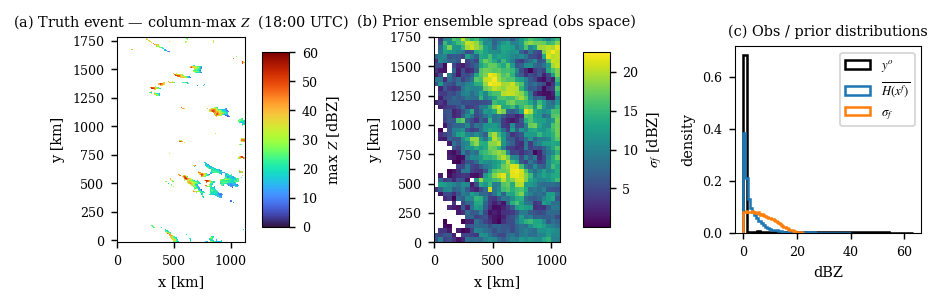

In [11]:
# ── Case study (tm00): event + prior ensemble spread ─────────────────────────
SUBSET_FILE = ('/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/'
               '3D_subsets_20240319_GUES_20240319180000/subset_20240319180000.npz')
pos_km = np.load(SUBSET_FILE)['pos_km']             # (nx,ny,nz,3)
x2d = pos_km[:, :, 0, 0]; y2d = pos_km[:, :, 0, 1]  # (nx,ny) in km

# truth reflectivity field (loc-independent) for the event panel
tk = np.load(os.path.join(ref_folder,
     f'WS_multiobs_1800_LOC{REF_LOC}_multi_obs_TEnKF_Nt01_as1.0_'
     f'Lx{REF_LOC}Ly{REF_LOC}Lz{REF_LOC}_Ne040_tm00.npz'), allow_pickle=True)
truth_refl_max = np.nanmax(tk['truth_hx_field'], axis=2)   # (nx,ny) max over z

# prior ensemble spread (obs space): same for all loc/ntemp -> take one slice
CASE_LOC, CASE_NT = 2.0, 1
sub = df[(df.loc_scale == CASE_LOC) & (df.ntemp == CASE_NT)]

def coarse_map_km(sub, col, pos_km, stride=20, agg='max'):
    g = sub.copy()
    g['bi'] = (g['i'] // stride).astype(int)
    g['bj'] = (g['j'] // stride).astype(int)
    a = g.groupby(['bi', 'bj'])[col].agg(agg).reset_index()
    nbi, nbj = g['bi'].max() + 1, g['bj'].max() + 1
    grid = np.full((nbi, nbj), np.nan)
    grid[a['bi'].values, a['bj'].values] = a[col].values
    xb = np.clip(np.arange(nbi) * stride, 0, pos_km.shape[0] - 1)
    yb = np.clip(np.arange(nbj) * stride, 0, pos_km.shape[1] - 1)
    return pos_km[xb, 0, 0, 0], pos_km[0, yb, 0, 1], grid

xb_km, yb_km, spread2d = coarse_map_km(sub, 'spread_f_obs', pos_km, stride=20, agg='max')

fig, axes = plt.subplots(1, 3, figsize=(PAGE_W, PAGE_W / 3.1),
                         constrained_layout=True)

# (a) event — full truth reflectivity field
ax = axes[0]
ext_a = [x2d.min(), x2d.max(), y2d.min(), y2d.max()]
im = ax.imshow(np.where(truth_refl_max > 0, truth_refl_max, np.nan).T,
               origin='lower', extent=ext_a, cmap='turbo',
               vmin=0, vmax=60, aspect='equal')
fig.colorbar(im, ax=ax, label='max $Z$ [dBZ]', shrink=0.85)
ax.set_title('(a) Truth event — column-max $Z$  (18:00 UTC)')
ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')

# (b) prior ensemble spread (obs space), coarse sweep grid
ax = axes[1]
ext_b = [xb_km.min(), xb_km.max(), yb_km.min(), yb_km.max()]
im = ax.imshow(spread2d.T, origin='lower', extent=ext_b,
               cmap='viridis', aspect='equal')
fig.colorbar(im, ax=ax, label=r'$\sigma_f$ [dBZ]', shrink=0.85)
ax.set_title('(b) Prior ensemble spread (obs space)')
ax.set_xlabel('x [km]'); ax.set_ylabel('y [km]')

# (c) obs / prior distributions
ax = axes[2]
for col, c, lab in [('yo_clean', 'k', r'$y^o$'),
                    ('hxf_mean_obs', 'tab:blue', r'$\overline{H(x^f)}$'),
                    ('spread_f_obs', 'tab:orange', r'$\sigma_f$')]:
    ax.hist(sub[col].dropna(), bins=50, density=True, histtype='step',
            linewidth=1.4, color=c, label=lab)
ax.set_title('(c) Obs / prior distributions')
ax.set_xlabel('dBZ'); ax.set_ylabel('density'); ax.legend()
ax.set_box_aspect(1)   # keep panel (c) square-ish next to the maps

#save_fig(fig, 'figC_case_tm00')
plt.show()

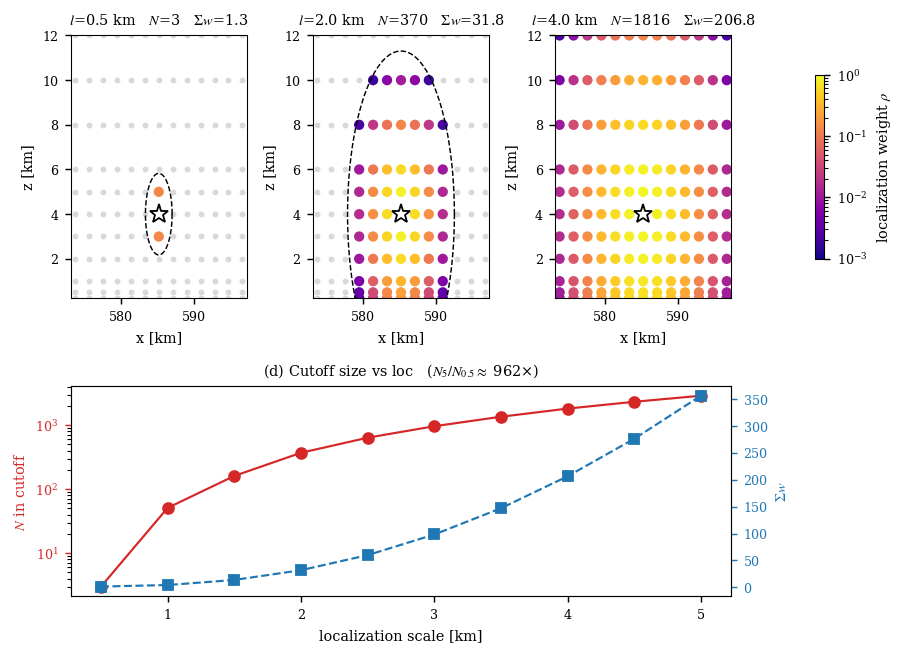

In [12]:
# ============================================================
# FIGURE 1 — fairness motivation: cutoff coverage grows with loc
# ============================================================
D2_CUTOFF = (2.0 * np.sqrt(10.0 / 3.0)) ** 2     # single-obs path (run_experiment.py)
R_CUT     = np.sqrt(D2_CUTOFF)

nx, ny, nz = pos_km.shape[:3]
dx = float(pos_km[1, 0, 0, 0] - pos_km[0, 0, 0, 0])
dy = float(pos_km[0, 1, 0, 1] - pos_km[0, 0, 0, 1])
i0, j0, k_obs = nx // 2, ny // 2, nz // 2
x0 = float(pos_km[i0, j0, k_obs, 0])
y0 = float(pos_km[i0, j0, k_obs, 1])
z0 = float(pos_km[i0, j0, k_obs, 2])

def cutoff_stats_3d(l):
    hi, hj = int(np.ceil(4 * l / dx)), int(np.ceil(4 * l / dy))
    sub = pos_km[max(0, i0-hi):i0+hi+1, max(0, j0-hj):j0+hj+1, :, :]
    d2 = (((sub[..., 0]-x0)/l)**2 + ((sub[..., 1]-y0)/l)**2 + ((sub[..., 2]-z0)/l)**2)
    m = d2 <= D2_CUTOFF
    return int(m.sum()), float(np.where(m, np.exp(-0.5 * d2), 0.0).sum())

# cross-section geometry at j=j0
win = 16
ir = np.arange(max(0, i0-win), min(nx, i0+win+1))
xc = pos_km[ir, j0, :, 0]; zc = pos_km[ir, j0, :, 2]
theta = np.linspace(0, 2*np.pi, 200)

LOC_CS  = [0.5, 2.0, 4.0]
norm_w  = mcolors.LogNorm(vmin=1e-3, vmax=1)

fig = plt.figure(figsize=(PAGE_W, PAGE_W * 0.72), constrained_layout=True)
gs  = fig.add_gridspec(2, 3, height_ratios=[1.25, 1.0])
cs_axes = [fig.add_subplot(gs[0, c]) for c in range(3)]
ax_d    = fig.add_subplot(gs[1, :])

sc = None
for ax, l in zip(cs_axes, LOC_CS):
    d2 = ((xc-x0)/l)**2 + ((zc-z0)/l)**2
    m  = d2 <= D2_CUTOFF
    ax.scatter(xc, zc, s=5, c='0.85')                          # full grid
    sc = ax.scatter(xc[m], zc[m], c=np.exp(-0.5*d2[m]),
                    cmap='plasma', norm=norm_w, s=22)
    ax.plot(x0 + R_CUT*l*np.cos(theta), z0 + R_CUT*l*np.sin(theta), 'k--', lw=0.8)
    ax.plot(x0, z0, marker='*', color='white', mec='k', ms=11, zorder=5)
    N, Sw = cutoff_stats_3d(l)
    ax.set_title(f'$l$={l} km   $N$={N}   $\\Sigma w$={Sw:.1f}')
    ax.set_xlabel('x [km]'); ax.set_ylabel('z [km]')
    ax.set_xlim(x0-12, x0+12); ax.set_ylim(zc.min(), zc.max())

fig.colorbar(sc, ax=cs_axes, shrink=0.7, label=r'localization weight $\rho$')

# (d) cutoff size vs loc
Ns, Sws = zip(*[cutoff_stats_3d(l) for l in LOC_SCALES])
ax_d.plot(LOC_SCALES, Ns, 'o-', color='tab:red', label='$N$ points')
ax_d.set_yscale('log')
ax_d.set_xlabel('localization scale [km]')
ax_d.set_ylabel('$N$ in cutoff', color='tab:red')
ax_d.tick_params(axis='y', colors='tab:red')
axb = ax_d.twinx()
axb.plot(LOC_SCALES, Sws, 's--', color='tab:blue')
axb.set_ylabel(r'$\Sigma w$', color='tab:blue'); axb.tick_params(axis='y', colors='tab:blue')
ax_d.set_title(f'(d) Cutoff size vs loc   '
               f'($N_{{5}}/N_{{0.5}} \\approx$ {Ns[-1]/max(Ns[0],1):.0f}×)')

#save_fig(fig, 'fig1_fairness_cutoff')
plt.show()

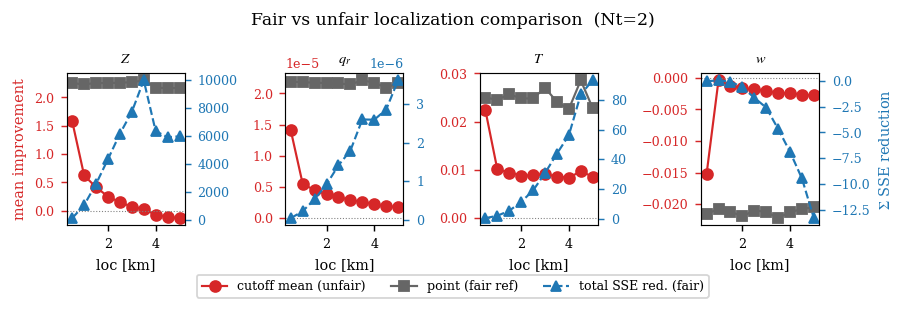

In [13]:
# ============================================================
# FIGURE 2 — fair vs unfair dRMSE vs localization
# ============================================================
NT_FOCUS = 2
VARS_F2  = ['obs', 'qr', 'T', 'w']

def fair_unfair_curves(df, var, nt):
    sub = df[df.ntemp == nt]
    locs = np.array(sorted(sub.loc_scale.unique()))
    imp_cutoff = -sub.groupby('loc_scale')[f'drmse_u_{var}'].mean().reindex(locs).values
    imp_point  = -sub.groupby('loc_scale')[f'drmse_point_{var}'].mean().reindex(locs).values
    sse_red = sub['n_updated'] * (sub[f'rmse_f_u_{var}']**2 - sub[f'rmse_a_u_{var}']**2)
    imp_fair = sse_red.groupby(sub['loc_scale']).mean().reindex(locs).values
    return locs, imp_cutoff, imp_point, imp_fair

fig, axes = plt.subplots(1, len(VARS_F2), figsize=(PAGE_W, PAGE_W / 3.3),
                         constrained_layout=True)
axes = np.atleast_1d(axes)
handles = []
for i, (ax, var) in enumerate(zip(axes, VARS_F2)):
    locs, c_cut, c_pt, c_fair = fair_unfair_curves(df, var, NT_FOCUS)
    l1, = ax.plot(locs, c_cut, 'o-',  color='tab:red', label='cutoff mean (unfair)')
    l2, = ax.plot(locs, c_pt,  's-',  color='0.4',     label='point (fair ref)')
    axb = ax.twinx()
    l3, = axb.plot(locs, c_fair, '^--', color='tab:blue', label='total SSE red. (fair)')
    ax.axhline(0, color='gray', lw=0.6, ls=':')
    ax.set_title(VAR_LABELS.get(var, var)); ax.set_xlabel('loc [km]')
    ax.tick_params(axis='y', colors='tab:red'); axb.tick_params(axis='y', colors='tab:blue')
    if i == 0:            ax.set_ylabel('mean improvement', color='tab:red')
    if i == len(axes)-1:  axb.set_ylabel(r'$\Sigma$ SSE reduction', color='tab:blue')
    handles = [l1, l2, l3]

fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.10))
fig.suptitle(f'Fair vs unfair localization comparison  (Nt={NT_FOCUS})')
#save_fig(fig, f'fig2_fair_vs_unfair_Nt{NT_FOCUS}')
plt.show()

In [14]:
# ============================================================
# FIGURE 3 — multi-obs localization map (normalized across variables)
# ============================================================
DOMAIN_F3 = 'storm'                 # 'global' | 'storm' | 'obs'
MODE      = 'percent'               # 'percent' (relative dRMSE %) | 'rownorm' (each var to its own max)
loc_arr   = np.array(sorted(df_multi.loc_scale.unique()))

def cell_value(sub, vn, lo):
    r = sub[sub.loc_scale == lo]
    if not len(r): return np.nan
    d  = r[f'drmse_{DOMAIN_F3}_{vn}'].values[0]
    rf = r[f'rmse_f_{DOMAIN_F3}_{vn}'].values[0]
    if MODE == 'percent':
        return 100.0 * d / rf if (rf and np.isfinite(rf)) else np.nan
    return d

mats = {}
for nt in NTEMPS:
    sub = df_multi[df_multi.ntemp == nt]
    m = np.array([[cell_value(sub, vn, lo) for lo in loc_arr] for vn in STATE_VARS])
    if MODE == 'rownorm':
        denom = np.nanmax(np.abs(m), axis=1, keepdims=True)
        m = m / np.where(denom == 0, np.nan, denom)
    mats[nt] = m

allvals = np.concatenate([mats[nt].ravel() for nt in NTEMPS])
vmax = 1.0 if MODE == 'rownorm' else np.nanpercentile(np.abs(allvals), 95)
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
cb_label = {'percent': f'relative dRMSE [%] ({DOMAIN_F3})',
            'rownorm': f'dRMSE normalized per variable ({DOMAIN_F3})'}[MODE]

fig, axes = plt.subplots(1, len(NTEMPS), figsize=(PAGE_W, PAGE_W * 0.42),
                         constrained_layout=True, sharey=True)
axes = np.atleast_1d(axes); im = None
for ax, nt in zip(axes, NTEMPS):
    m = mats[nt]
    im = ax.imshow(m, cmap='RdBu_r', norm=norm, aspect='auto')
    for vi in range(len(STATE_VARS)):
        if np.all(np.isnan(m[vi])): continue
        ax.plot(np.nanargmin(m[vi]), vi, 'o', mfc='none', mec='k', ms=6, mew=1.0)
    ax.set_xticks(range(len(loc_arr)))
    ax.set_xticklabels([f'{l:g}' for l in loc_arr], rotation=45, fontsize=6)
    ax.set_yticks(range(len(STATE_VARS)))
    ax.set_yticklabels([VAR_LABELS.get(v, v) for v in STATE_VARS])
    ax.set_title(f'Nt={nt}'); ax.set_xlabel('loc [km]')

fig.colorbar(im, ax=list(axes), shrink=0.85, label=cb_label + '  (blue = improvement)')
fig.suptitle('Multi-obs localization map — dRMSE per variable')
#save_fig(fig, f'fig3_multiobs_heatmap_{DOMAIN_F3}_{MODE}')
plt.show()

NameError: name 'df_multi' is not defined

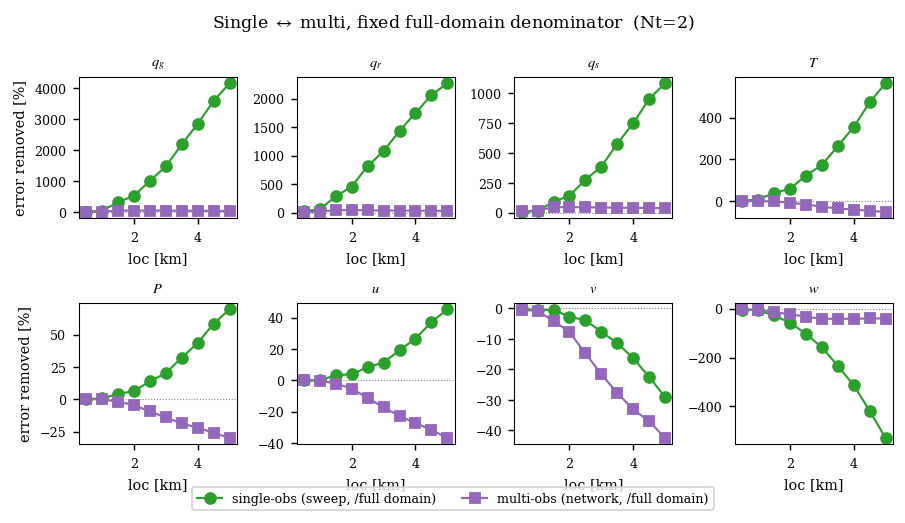

In [8]:
# ============================================================
# FIGURE 3b — single <-> multi bridge, fixed full-domain denominator
# Both experiments share the same Fortran DA cutoff -> shared x-axis.
# ============================================================
NT_FOCUS  = 2
X_AXIS    = 'loc'             # 'loc' (nominal) | 'phys_radius'
NORMALIZE = False            # True -> each curve to its own |max| (shape only)
N_FULL    = float(np.prod(truth.shape[:3]))       # constant full-domain point count
CUT       = np.sqrt(2.0 * np.sqrt(10.0/3.0))      # ≈1.91, current effective reach (same for both)
loc_arr   = np.array(sorted(set(df.loc_scale.unique()) & set(df_multi.loc_scale.unique())))

def single_reduc(var, lo, nt):
    s = df[(df.ntemp == nt) & (df.loc_scale == lo)]
    dSSE  = (s['n_updated'] * (s[f'rmse_f_u_{var}']**2 - s[f'rmse_a_u_{var}']**2)).sum()
    mse_f = df_multi[f'rmse_f_global_{var}'].iloc[0]**2     # shared, loc-independent prior
    return 100.0 * dSSE / (mse_f * N_FULL)

def multi_reduc(var, lo, nt):
    r = df_multi[(df_multi.ntemp == nt) & (df_multi.loc_scale == lo)]
    if not len(r): return np.nan
    f2 = r[f'rmse_f_global_{var}'].values[0]**2
    a2 = r[f'rmse_a_global_{var}'].values[0]**2
    return 100.0 * (f2 - a2) / f2

x    = loc_arr * CUT if X_AXIS == 'phys_radius' else loc_arr
xlab = 'physical cutoff radius [km]' if X_AXIS == 'phys_radius' else 'loc [km]'

fig, axes = plt.subplots(2, 4, figsize=(PAGE_W, PAGE_W*0.55), constrained_layout=True)
l1 = l2 = None
for ax, var in zip(axes.flat, STATE_VARS):
    rs = np.array([single_reduc(var, lo, NT_FOCUS) for lo in loc_arr])
    rm = np.array([multi_reduc(var, lo, NT_FOCUS)  for lo in loc_arr])
    if NORMALIZE:
        rs = rs/np.nanmax(np.abs(rs)); rm = rm/np.nanmax(np.abs(rm))
    l1, = ax.plot(x, rs, 'o-', color='tab:green',  label='single-obs (sweep, /full domain)')
    l2, = ax.plot(x, rm, 's-', color='tab:purple', label='multi-obs (network, /full domain)')
    ax.axhline(0, color='gray', lw=0.6, ls=':')
    ax.set_title(VAR_LABELS.get(var, var)); ax.set_xlabel(xlab)
axes[0,0].set_ylabel('error removed [%]'); axes[1,0].set_ylabel('error removed [%]')
fig.legend(handles=[l1, l2], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f'Single $\\leftrightarrow$ multi, fixed full-domain denominator  (Nt={NT_FOCUS})')
#save_fig(fig, f'fig3b_fixeddomain_Nt{NT_FOCUS}_{X_AXIS}')
plt.show()

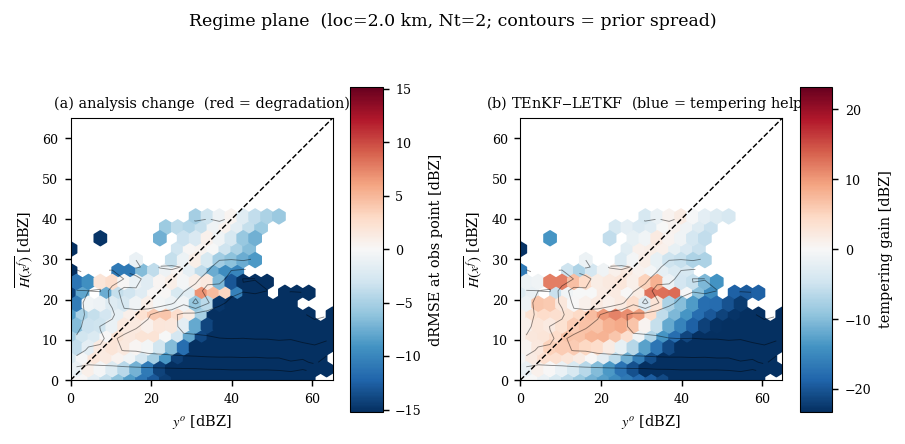

In [9]:
# ============================================================
# FIGURE 4 — regime plane (yo vs hxf): degradation & tempering gain
# ============================================================
VAR_F4    = 'obs'          # color metric: 'obs' (reflectivity) or a state var
NT_FOCUS  = 2
LOC_FOCUS = 2.0
GRID, MINCNT = 22, 10
XEXT, YEXT = [0, 65], [0, 65]      # both clipped at the 0 dBZ floor

base = df[(df.ntemp == NT_FOCUS) & (df.loc_scale == LOC_FOCUS)].copy()
letk = (df[(df.ntemp == 1) & (df.loc_scale == LOC_FOCUS)]
        [['i','j','k', f'drmse_point_{VAR_F4}']]
        .rename(columns={f'drmse_point_{VAR_F4}': '_letkf'}))
base = base.merge(letk, on=['i','j','k'], how='left')
base['temp_gain'] = base[f'drmse_point_{VAR_F4}'] - base['_letkf']

x  = base['yo_clean'].values
y  = base['hxf_mean_obs'].values
sp = base['spread_f_obs'].values

# spread contour grid (nonlinearity proxy)
m0 = np.isfinite(x) & np.isfinite(y) & np.isfinite(sp)
Hs, xe, ye = np.histogram2d(x[m0], y[m0], bins=GRID, range=[XEXT, YEXT], weights=sp[m0])
Hn, _, _   = np.histogram2d(x[m0], y[m0], bins=GRID, range=[XEXT, YEXT])
with np.errstate(invalid='ignore'):
    spread_grid = (Hs / Hn).T
xc, yc = 0.5*(xe[:-1]+xe[1:]), 0.5*(ye[:-1]+ye[1:])

panels = [(f'drmse_point_{VAR_F4}', '(a) analysis change  (red = degradation)', 'dRMSE at obs point [dBZ]'),
          ('temp_gain',             f'(b) TEnKF$-$LETKF  (blue = tempering helps)', 'tempering gain [dBZ]')]

fig, axes = plt.subplots(1, 2, figsize=(PAGE_W, PAGE_W*0.5), constrained_layout=True)
for ax, (col, title, cblab) in zip(axes, panels):
    c = base[col].values
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)
    vlim = np.nanpercentile(np.abs(c[m]), 95)
    hb = ax.hexbin(x[m], y[m], C=c[m], gridsize=GRID, extent=XEXT+YEXT,
                   reduce_C_function=np.mean, cmap='RdBu_r',
                   vmin=-vlim, vmax=vlim, mincnt=MINCNT)
    ax.plot(XEXT, XEXT, 'k--', lw=0.8)                          # zero-departure diagonal
    cs = ax.contour(xc, yc, spread_grid, levels=4, colors='k', linewidths=0.5, alpha=0.45)
    fig.colorbar(hb, ax=ax, shrink=0.8, label=cblab)
    ax.set_title(title)
    ax.set_xlabel(r'$y^o$ [dBZ]'); ax.set_ylabel(r'$\overline{H(x^f)}$ [dBZ]')
    ax.set_aspect('equal'); ax.set_xlim(XEXT); ax.set_ylim(YEXT)

fig.suptitle(f'Regime plane  (loc={LOC_FOCUS} km, Nt={NT_FOCUS}; contours = prior spread)')
#save_fig(fig, f'fig4_regime_plane_{VAR_F4}_Nt{NT_FOCUS}_loc{LOC_FOCUS}')
plt.show()

In [10]:
# ============================================================
# Precompute: reflectivity operator (Smith 1975) + Jensen gap on df
# ============================================================
RD, PI = 287.0, np.pi
def calc_ref(qr, qs, qg, T, P, min_dbz=0.0):
    pip = PI**1.75
    cf  = 1e18*720/(pip*(8.0e6**0.75)*(1000.0**1.75))
    cf2 = 1e18*720*0.176*(100.0**0.25)/(pip*0.930*(2.0e6**0.75)*(917.0**2))
    cf3 = 1e18*720/(pip*(2.0e6**0.75)*(100.0**1.75))
    cf4 = (1e18*720/(pip*(4.0e6**0.75)*(913.0**1.75)))**0.95
    ro  = P/(RD*T)
    qr, qs, qg = np.clip(qr,0,None), np.clip(qs,0,None), np.clip(qg,0,None)
    zr = np.where(qr>0, cf*(ro*qr)**1.75, 0.0)
    zs = np.where(qs>0, np.where(T<=273.16, cf2, cf3)*(ro*qs)**1.75, 0.0)
    zg = np.where(qg>0, cf4*(ro*qg)**1.6625, 0.0)
    ref = zr+zs+zg
    out = np.where(ref>0, 10*np.log10(np.where(ref>0, ref, 1.0)), min_dbz)
    return np.maximum(out, min_dbz)

# H(x̄) at the unique sweep points (xf_mean order: qg,qr,qs,T,P,...)
vi = {'qg':0, 'qr':1, 'qs':2, 'T':3, 'P':4}
swp = df[['i','j','k']].drop_duplicates()
ii, jj, kk = swp['i'].astype(int).values, swp['j'].astype(int).values, swp['k'].astype(int).values
xm = xf_mean[ii, jj, kk, :]
swp = swp.assign(Hxbar=calc_ref(xm[:,vi['qr']], xm[:,vi['qs']], xm[:,vi['qg']],
                                xm[:,vi['T']],  xm[:,vi['P']], min_dbz=0.0))
df = df.merge(swp, on=['i','j','k'], how='left')
df['jensen'] = df['Hxbar'] - df['hxf_mean_obs']     # G = H(x̄) − ⟨H(x)⟩
print('Jensen gap added. range:', np.nanpercentile(df['jensen'], [1,50,99]))

Jensen gap added. range: [-1.54962325  5.24411671 26.25259019]


saved fig5_innov_nonlin_Nt2.pdf / fig5_innov_nonlin_Nt2.png


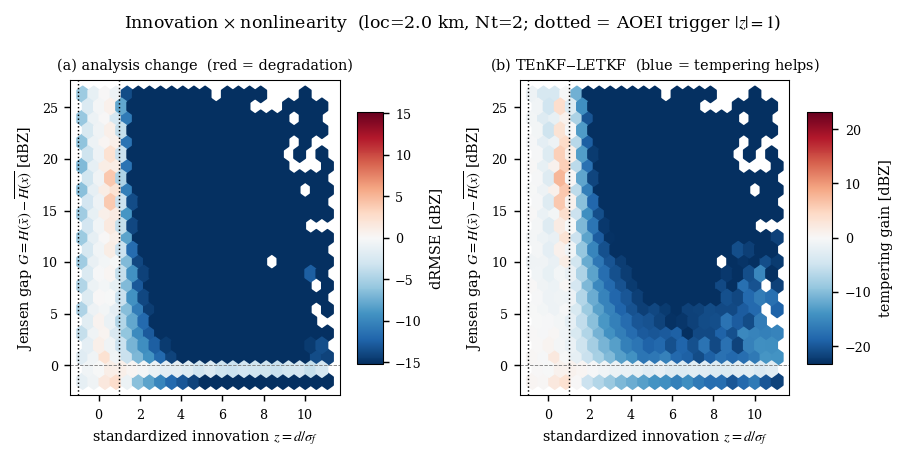

In [11]:
# ============================================================
# FIGURE 5 — standardized innovation × nonlinearity (Jensen gap)
# ============================================================
VAR_F5, NT_FOCUS, LOC_FOCUS = 'obs', 2, 2.0
GRID, MINCNT = 22, 10

base = df[(df.ntemp==NT_FOCUS) & (df.loc_scale==LOC_FOCUS)].copy()
letk = (df[(df.ntemp==1) & (df.loc_scale==LOC_FOCUS)][['i','j','k', f'drmse_point_{VAR_F5}']]
        .rename(columns={f'drmse_point_{VAR_F5}': '_letkf'}))
base = base.merge(letk, on=['i','j','k'], how='left')
base['temp_gain'] = base[f'drmse_point_{VAR_F5}'] - base['_letkf']

z = base['dep_b'].values / base['spread_f_obs'].values     # standardized innovation
g = base['jensen'].values
zlim = (np.nanpercentile(z[np.isfinite(z)], 1), np.nanpercentile(z[np.isfinite(z)], 99))
glim = (np.nanpercentile(g[np.isfinite(g)], 1), np.nanpercentile(g[np.isfinite(g)], 99))

panels = [(f'drmse_point_{VAR_F5}', '(a) analysis change  (red = degradation)', 'dRMSE [dBZ]'),
          ('temp_gain',             '(b) TEnKF$-$LETKF  (blue = tempering helps)', 'tempering gain [dBZ]')]
fig, axes = plt.subplots(1, 2, figsize=(PAGE_W, PAGE_W*0.5), constrained_layout=True)
for ax, (col, title, cblab) in zip(axes, panels):
    c = base[col].values
    m = np.isfinite(z) & np.isfinite(g) & np.isfinite(c)
    vlim = np.nanpercentile(np.abs(c[m]), 95)
    hb = ax.hexbin(z[m], g[m], C=c[m], gridsize=GRID,
                   extent=[zlim[0], zlim[1], glim[0], glim[1]],
                   reduce_C_function=np.mean, cmap='RdBu_r', vmin=-vlim, vmax=vlim, mincnt=MINCNT)
    ax.axvline(1, color='k', ls=':', lw=0.8); ax.axvline(-1, color='k', ls=':', lw=0.8)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    fig.colorbar(hb, ax=ax, shrink=0.8, label=cblab)
    ax.set_title(title)
    ax.set_xlabel(r'standardized innovation $z=d/\sigma_f$')
    ax.set_ylabel(r'Jensen gap $G=H(\bar x)-\overline{H(x)}$ [dBZ]')
fig.suptitle(f'Innovation $\\times$ nonlinearity  (loc={LOC_FOCUS} km, Nt={NT_FOCUS}; dotted = AOEI trigger $|z|=1$)')
save_fig(fig, f'fig5_innov_nonlin_Nt{NT_FOCUS}')
plt.show()

In [12]:
# ── Config ───────────────────────────────────────────────────────────────────
DATA_ROOT      = '/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data'
FILTER_METHODS = ['LETKF', 'TEnKF', 'AOEI']     # keep all
FILTER_NTEMP   = NTEMPS
SUBSAMPLE, SUBSAMPLE_N = False, 500_000
EXPERIMENTS = [{'loc_scale': l,
                'directory': f'WS_sweep_test_1800_LOC{l}',
                'file_glob': f'WS_sweep_LOC{l}_sweep_Ne040_tm*.npz'} for l in LOC_SCALES]

# ── Build single-obs df (all methods) ─────────────────────────────────────────
all_dfs = []
for exp in EXPERIMENTS:
    loc, dirp = exp['loc_scale'], os.path.join(DATA_ROOT, exp['directory'])
    files = sorted(glob.glob(os.path.join(dirp, exp['file_glob'])))
    loc_dfs = []
    for fpath in files:
        try:
            raw = load_sweep_npz(fpath)
            keep = raw['method'].isin(FILTER_METHODS) & (
                   (raw['method'] != 'TEnKF') | raw['ntemp'].isin(FILTER_NTEMP))
            raw = raw[keep]
            raw['loc_scale'] = loc
            loc_dfs.append(raw)
        except Exception as e:
            print(f'  SKIP {os.path.basename(fpath)}: {e}')
    if not loc_dfs:
        print(f'loc={loc}: NO files'); continue
    loc_df = pd.concat(loc_dfs, ignore_index=True)
    if SUBSAMPLE:
        loc_df = loc_df.sample(n=min(SUBSAMPLE_N, len(loc_df)), random_state=42).reset_index(drop=True)
    all_dfs.append(loc_df)

df = add_derived_cols(pd.concat(all_dfs, ignore_index=True))
print(f'rows: {len(df):,}')
print(df.groupby(['method', 'ntemp']).size())     # <-- check AOEI / LETKF are present

rows: 16,248,640
method  ntemp
TEnKF   1        4062160
        2        4062160
        3        4062160
        5        4062160
dtype: int64


In [13]:
# ── Jensen-gap precompute (run AFTER cell 2; safe to re-run) ──────────────────
RD, PI = 287.0, np.pi
def calc_ref(qr, qs, qg, T, P, min_dbz=0.0):
    pip = PI**1.75
    cf  = 1e18*720/(pip*(8.0e6**0.75)*(1000.0**1.75))
    cf2 = 1e18*720*0.176*(100.0**0.25)/(pip*0.930*(2.0e6**0.75)*(917.0**2))
    cf3 = 1e18*720/(pip*(2.0e6**0.75)*(100.0**1.75))
    cf4 = (1e18*720/(pip*(4.0e6**0.75)*(913.0**1.75)))**0.95
    ro  = P/(RD*T)
    qr, qs, qg = np.clip(qr,0,None), np.clip(qs,0,None), np.clip(qg,0,None)
    zr = np.where(qr>0, cf*(ro*qr)**1.75, 0.0)
    zs = np.where(qs>0, np.where(T<=273.16, cf2, cf3)*(ro*qs)**1.75, 0.0)
    zg = np.where(qg>0, cf4*(ro*qg)**1.6625, 0.0)
    ref = zr+zs+zg
    out = np.where(ref>0, 10*np.log10(np.where(ref>0, ref, 1.0)), min_dbz)
    return np.maximum(out, min_dbz)

df = df.drop(columns=[c for c in ('Hxbar','jensen') if c in df.columns])   # idempotent
vi = {'qg':0, 'qr':1, 'qs':2, 'T':3, 'P':4}
swp = df[['i','j','k']].drop_duplicates()
ii, jj, kk = swp['i'].astype(int).values, swp['j'].astype(int).values, swp['k'].astype(int).values
xm = xf_mean[ii, jj, kk, :]
swp = swp.assign(Hxbar=calc_ref(xm[:,vi['qr']], xm[:,vi['qs']], xm[:,vi['qg']],
                                xm[:,vi['T']],  xm[:,vi['P']], min_dbz=0.0))
df = df.merge(swp, on=['i','j','k'], how='left')
df['jensen'] = df['Hxbar'] - df['hxf_mean_obs']
print('jensen present:', 'jensen' in df.columns)

jensen present: True


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


saved fig6_method_diffs.pdf / fig6_method_diffs.png


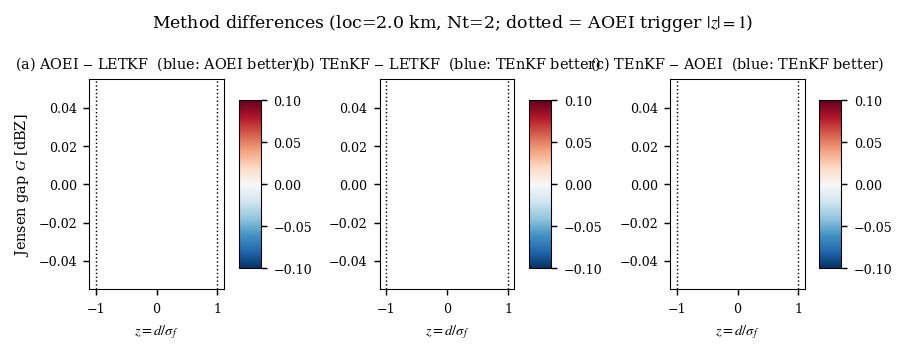

In [14]:
# ============================================================
# FIGURE 6 — method differences on the (z, G) plane
# ============================================================
VAR_F6, NT_FOCUS, LOC_FOCUS = 'obs', 2, 2.0
GRID, MINCNT = 22, 10
COLS = ['i','j','k', f'drmse_point_{VAR_F6}', 'dep_b', 'spread_f_obs', 'jensen']

def mslice(method, nt=None):
    q = (df.method == method) & (df.loc_scale == LOC_FOCUS)
    if nt is not None: q &= (df.ntemp == nt)
    return df.loc[q, COLS]

base = (mslice('LETKF') if (df.method == 'LETKF').any() else mslice('TEnKF', 1))
base = base.rename(columns={f'drmse_point_{VAR_F6}': 'letkf'})
aoei = mslice('AOEI').rename(columns={f'drmse_point_{VAR_F6}': 'aoei'})[['i','j','k','aoei']]
tenk = mslice('TEnKF', NT_FOCUS).rename(columns={f'drmse_point_{VAR_F6}': 'tenkf'})[['i','j','k','tenkf']]

M = base.merge(aoei, on=['i','j','k']).merge(tenk, on=['i','j','k'])
M['z'] = M['dep_b'] / M['spread_f_obs']
M['aoei_letkf']  = M['aoei']  - M['letkf']
M['tenkf_letkf'] = M['tenkf'] - M['letkf']
M['tenkf_aoei']  = M['tenkf'] - M['aoei']

x, y = M['z'].values, M['jensen'].values
zlim = (np.nanpercentile(x,1), np.nanpercentile(x,99))
glim = (np.nanpercentile(y,1), np.nanpercentile(y,99))

panels = [('aoei_letkf',  '(a) AOEI $-$ LETKF  (blue: AOEI better)'),
          ('tenkf_letkf', '(b) TEnKF $-$ LETKF  (blue: TEnKF better)'),
          ('tenkf_aoei',  '(c) TEnKF $-$ AOEI  (blue: TEnKF better)')]
fig, axes = plt.subplots(1, 3, figsize=(PAGE_W, PAGE_W*0.38), constrained_layout=True)
for ax, (col, title) in zip(axes, panels):
    c = M[col].values
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)
    vlim = np.nanpercentile(np.abs(c[m]), 95)
    hb = ax.hexbin(x[m], y[m], C=c[m], gridsize=GRID, extent=[*zlim, *glim],
                   reduce_C_function=np.mean, cmap='RdBu_r', vmin=-vlim, vmax=vlim, mincnt=MINCNT)
    ax.axvline(1, color='k', ls=':', lw=0.8); ax.axvline(-1, color='k', ls=':', lw=0.8)
    fig.colorbar(hb, ax=ax, shrink=0.8)
    ax.set_title(title); ax.set_xlabel(r'$z=d/\sigma_f$')
    if ax is axes[0]: ax.set_ylabel(r'Jensen gap $G$ [dBZ]')
fig.suptitle(f'Method differences (loc={LOC_FOCUS} km, Nt={NT_FOCUS}; dotted = AOEI trigger $|z|=1$)')
save_fig(fig, 'fig6_method_diffs')
plt.show()

In [16]:
print(df.groupby(['method','ntemp']).size())
print('lens  base/aoei/tenk/M:', len(base), len(aoei), len(tenk), len(M))
if len(M):
    print('M.jensen range:', np.nanmin(M['jensen']), np.nanmax(M['jensen']))
    print('M.z range    :', np.nanmin(M['z']), np.nanmax(M['z']))

method  ntemp
TEnKF   1        4062160
        2        4062160
        3        4062160
        5        4062160
dtype: int64
lens  base/aoei/tenk/M: 406216 0 406216 0


saved fig6_aoei_activity.pdf / fig6_aoei_activity.png


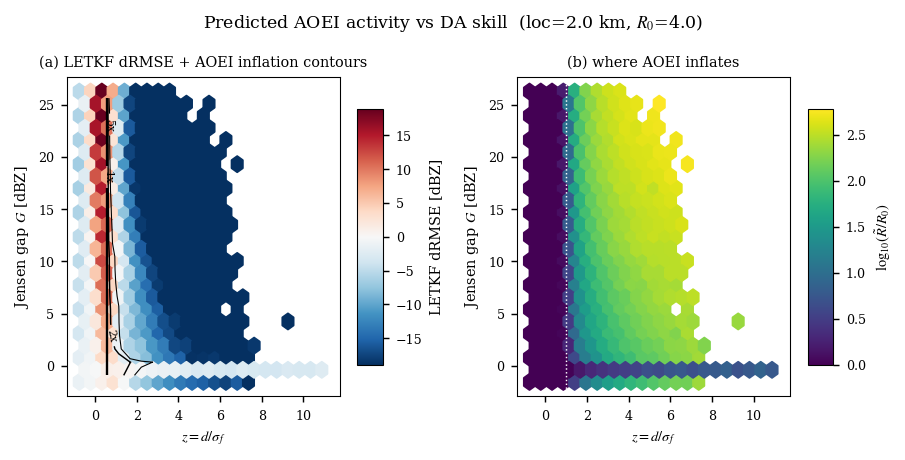

In [17]:
# ============================================================
# FIGURE 6 (interim) — predicted AOEI activity vs DA skill
# (AOEI sweeps not yet available; computed from d, sigma_f, R0)
# ============================================================
R0 = 4.0          # <-- set to your nominal obs error variance [dBZ^2]
LOC_FOCUS, GRID, MINCNT = 2.0, 22, 10

b = df[(df.method=='TEnKF') & (df.ntemp==1) & (df.loc_scale==LOC_FOCUS)].copy()
b['z']    = b['dep_b'] / b['spread_f_obs']
b['infl'] = np.maximum(1.0, (b['dep_b']**2 - b['spread_f_obs']**2) / R0)   # R̃/R0

x, y = b['z'].values, b['jensen'].values
m = np.isfinite(x) & np.isfinite(y)
zlim = (np.nanpercentile(x[m],1), np.nanpercentile(x[m],99))
glim = (np.nanpercentile(y[m],1), np.nanpercentile(y[m],99))

Hi,xe,ye = np.histogram2d(x[m], y[m], bins=GRID, range=[list(zlim),list(glim)], weights=b['infl'].values[m])
Hn,_,_   = np.histogram2d(x[m], y[m], bins=GRID, range=[list(zlim),list(glim)])
with np.errstate(invalid='ignore'): infl_grid = (Hi/Hn).T
xc, yc = 0.5*(xe[:-1]+xe[1:]), 0.5*(ye[:-1]+ye[1:])

fig, axes = plt.subplots(1, 2, figsize=(PAGE_W, PAGE_W*0.5), constrained_layout=True)

ax = axes[0]; c = b['drmse_point_obs'].values; mm = m & np.isfinite(c)
vlim = np.nanpercentile(np.abs(c[mm]), 95)
hb = ax.hexbin(x[mm], y[mm], C=c[mm], gridsize=GRID, extent=[*zlim,*glim],
               reduce_C_function=np.mean, cmap='RdBu_r', vmin=-vlim, vmax=vlim, mincnt=MINCNT)
cs = ax.contour(xc, yc, infl_grid, levels=[1.0,2.0,5.0], colors='k', linewidths=[1.3,0.8,0.6])
ax.clabel(cs, fmt='%.0fx', fontsize=6)
fig.colorbar(hb, ax=ax, shrink=0.8, label='LETKF dRMSE [dBZ]')
ax.set_title('(a) LETKF dRMSE + AOEI inflation contours')
ax.set_xlabel(r'$z=d/\sigma_f$'); ax.set_ylabel(r'Jensen gap $G$ [dBZ]')

ax = axes[1]
hb = ax.hexbin(x[m], y[m], C=np.log10(b['infl'].values[m]), gridsize=GRID, extent=[*zlim,*glim],
               reduce_C_function=np.mean, cmap='viridis', mincnt=MINCNT)
ax.axvline(1, color='w', ls=':', lw=0.8)
fig.colorbar(hb, ax=ax, shrink=0.8, label=r'$\log_{10}(\tilde R/R_0)$')
ax.set_title('(b) where AOEI inflates'); ax.set_xlabel(r'$z=d/\sigma_f$'); ax.set_ylabel(r'Jensen gap $G$ [dBZ]')

fig.suptitle(f'Predicted AOEI activity vs DA skill  (loc={LOC_FOCUS} km, $R_0$={R0})')
save_fig(fig, 'fig6_aoei_activity')
plt.show()

saved fig7_badzone_single_multi_qr.pdf / fig7_badzone_single_multi_qr.png


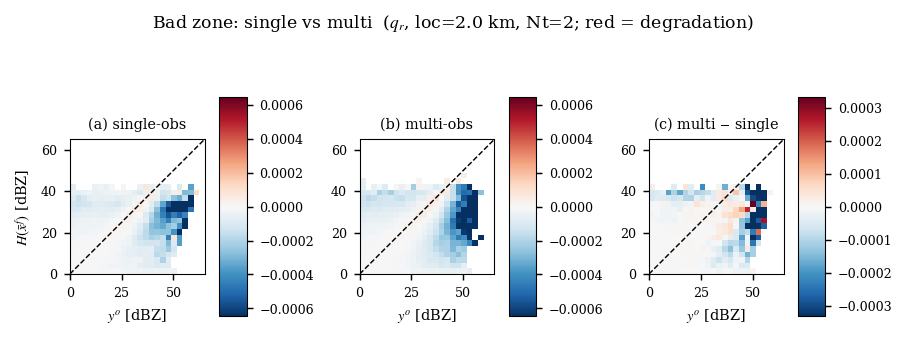

In [18]:
# ============================================================
# FIGURE 7 — bad zone: single-obs vs multi-obs (role of neighboring obs)
# ============================================================
VAR = 'qr'                       # state variable to compare ('qr','qs','qg','w',...)
NT_FOCUS, LOC_FOCUS = 2, 2.0
GRID, MINCNT = 24, 5
XEXT, YEXT = [0, 65], [0, 65]
vi8 = {v: i for i, v in enumerate(STATE_VARS)}

# single-obs: improvement at sweep points (y = H(x̄) for consistency with multi)
s  = df[(df.method=='TEnKF') & (df.ntemp==NT_FOCUS) & (df.loc_scale==LOC_FOCUS)]
xs, ys, cs = s['yo_clean'].values, s['Hxbar'].values, s[f'drmse_point_{VAR}'].values

# multi-obs: reload one file, index abs_err at obs points
l = str(LOC_FOCUS)
fpath = os.path.join(DATA_ROOT, f'WS_multiobs_1800_LOC{LOC_FOCUS}',
        f'WS_multiobs_1800_LOC{l}_multi_obs_TEnKF_Nt0{NT_FOCUS}_as1.0_Lx{l}Ly{l}Lz{l}_Ne040_tm00.npz')
d  = np.load(fpath, allow_pickle=True)
ea = d['abs_err_a_field'][obs_ix, obs_iy, obs_iz, vi8[VAR]]
ef = d['abs_err_f_field'][obs_ix, obs_iy, obs_iz, vi8[VAR]]
cm = ea - ef                                                   # improvement (neg = better)
xm = xf_mean[obs_ix, obs_iy, obs_iz, :]
ym = calc_ref(xm[:,1], xm[:,2], xm[:,0], xm[:,3], xm[:,4], min_dbz=0.0)   # H(x̄) at obs
xmlt = yo_clean

def binned_mean(x, y, c):
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)
    H,xe,ye = np.histogram2d(x[m], y[m], bins=GRID, range=[XEXT, YEXT], weights=c[m])
    N,_,_   = np.histogram2d(x[m], y[m], bins=GRID, range=[XEXT, YEXT])
    with np.errstate(invalid='ignore'): g = H / N
    g[N < MINCNT] = np.nan
    return g.T, xe, ye

gs, xe, ye = binned_mean(xs, ys, cs)
gm, _, _   = binned_mean(xmlt, ym, cm)
gd = gm - gs

vlim = np.nanpercentile(np.abs(np.concatenate([gs[np.isfinite(gs)], gm[np.isfinite(gm)]])), 95)
vld  = np.nanpercentile(np.abs(gd[np.isfinite(gd)]), 95)

fig, axes = plt.subplots(1, 3, figsize=(PAGE_W, PAGE_W*0.4), constrained_layout=True)
for ax, (g, vl, title) in zip(axes, [(gs, vlim, '(a) single-obs'),
                                     (gm, vlim, '(b) multi-obs'),
                                     (gd, vld,  '(c) multi $-$ single')]):
    im = ax.imshow(g, origin='lower', extent=[*XEXT, *YEXT], cmap='RdBu_r',
                   vmin=-vl, vmax=vl, aspect='equal')
    ax.plot(XEXT, XEXT, 'k--', lw=0.8)
    fig.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(title); ax.set_xlabel(r'$y^o$ [dBZ]')
axes[0].set_ylabel(r'$H(\bar x^f)$ [dBZ]')
fig.suptitle(f'Bad zone: single vs multi  ({VAR_LABELS.get(VAR,VAR)}, loc={LOC_FOCUS} km, Nt={NT_FOCUS}; red = degradation)')
save_fig(fig, f'fig7_badzone_single_multi_{VAR}')
plt.show()

saved fig7_badzone_obsspace.pdf / fig7_badzone_obsspace.png


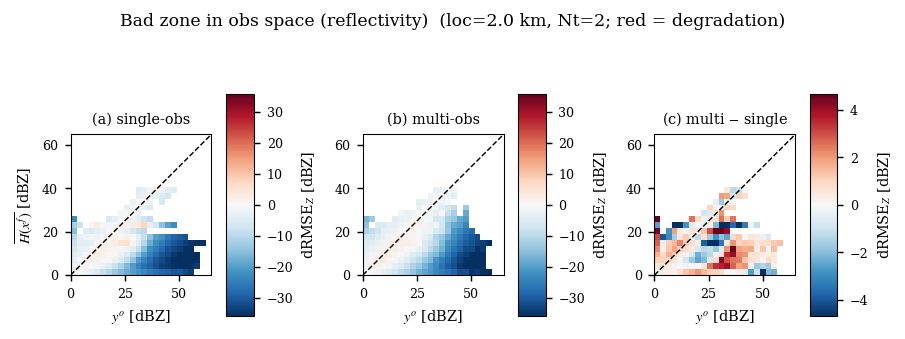

In [21]:
# ============================================================
# FIGURE 7 — bad zone in OBSERVATION SPACE (reflectivity): single vs multi
# ============================================================
NT_FOCUS, LOC_FOCUS = 2, 2.0
GRID, MINCNT = 24, 5
XEXT, YEXT = [0, 65], [0, 65]

# single-obs: reflectivity dRMSE at sweep points
s  = df[(df.method=='TEnKF') & (df.ntemp==NT_FOCUS) & (df.loc_scale==LOC_FOCUS)]
xs, ys, cs = s['yo_clean'].values, s['hxf_mean_obs'].values, s['drmse_point_obs'].values

# multi-obs: reflectivity error at obs points (from stored hx fields)
l = str(LOC_FOCUS)
fpath = os.path.join(DATA_ROOT, f'WS_multiobs_1800_LOC{LOC_FOCUS}',
        f'WS_multiobs_1800_LOC{l}_multi_obs_TEnKF_Nt0{NT_FOCUS}_as1.0_Lx{l}Ly{l}Lz{l}_Ne040_tm00.npz')
d = np.load(fpath, allow_pickle=True)
err_f = d['err_hxf_field'][obs_ix, obs_iy, obs_iz]      # hxf_mean − truth_hx
err_a = d['residual_field'][obs_ix, obs_iy, obs_iz]     # hxa_mean − truth_hx
cm  = np.abs(err_a) - np.abs(err_f)                     # reflectivity dRMSE (neg = better)
ym  = d['hxf_mean_field'][obs_ix, obs_iy, obs_iz]       # <H(x)> at obs
xmlt = yo_clean

def binned_mean(x, y, c):
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)
    H,xe,ye = np.histogram2d(x[m], y[m], bins=GRID, range=[XEXT, YEXT], weights=c[m])
    N,_,_   = np.histogram2d(x[m], y[m], bins=GRID, range=[XEXT, YEXT])
    with np.errstate(invalid='ignore'): g = H / N
    g[N < MINCNT] = np.nan
    return g.T, xe, ye

gs, xe, ye = binned_mean(xs, ys, cs)
gm, _, _   = binned_mean(xmlt, ym, cm)
gd = gm - gs
vlim = np.nanpercentile(np.abs(np.concatenate([gs[np.isfinite(gs)], gm[np.isfinite(gm)]])), 95)
vld  = np.nanpercentile(np.abs(gd[np.isfinite(gd)]), 95)

fig, axes = plt.subplots(1, 3, figsize=(PAGE_W, PAGE_W*0.4), constrained_layout=True)
for ax, (g, vl, title) in zip(axes, [(gs, vlim, '(a) single-obs'),
                                     (gm, vlim, '(b) multi-obs'),
                                     (gd, vld,  '(c) multi $-$ single')]):
    im = ax.imshow(g, origin='lower', extent=[*XEXT, *YEXT], cmap='RdBu_r',
                   vmin=-vl, vmax=vl, aspect='equal')
    ax.plot(XEXT, XEXT, 'k--', lw=0.8)
    fig.colorbar(im, ax=ax, shrink=0.7, label=r'dRMSE$_Z$ [dBZ]')
    ax.set_title(title); ax.set_xlabel(r'$y^o$ [dBZ]')
axes[0].set_ylabel(r'$\overline{H(x^f)}$ [dBZ]')
fig.suptitle(f'Bad zone in obs space (reflectivity)  (loc={LOC_FOCUS} km, Nt={NT_FOCUS}; red = degradation)')
save_fig(fig, 'fig7_badzone_obsspace')
plt.show()